In [3]:
import statistics
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from matplotlib.colors import ListedColormap
from matplotlib.font_manager import FontProperties
import numpy as np
import re


# Figure 1: data-preprossing

!wget -O /content/TimesNewRoman.ttf \
https://github.com/justrajdeep/fonts/raw/master/Times%20New%20Roman.ttf
font_path = "/content/TimesNewRoman.ttf"
fm.fontManager.addfont(font_path)
tnr_name = fm.FontProperties(fname=font_path).get_name()
plt.rcParams["font.family"] = tnr_name
print("Using font:", tnr_name)

acc = []
with open("rho_acc.txt", "r") as file:
    data = file.read()
    pattern = r'(?=((?:0|1)\.\d+?)(?=[.C]|$))'
    matches = [m.group(1) for m in re.finditer(pattern, data)]
    acc = [float(s) for s in matches]
    #rint(data.count("Current"))
    #print(len(matches))

with open('sgm_sd.txt', 'r') as file:
    float_string = file.read()
    float_string = float_string.lstrip('\ufeff').replace(' ', '')
    SGM_sd = list(map(float, float_string.split(",")))

with open('output.txt', 'r') as file:
    float_string = file.read()

    SGM = list(map(float, float_string.split(",")))
def cap_values(matrix):
    for i in range(len(matrix)):
        for j in range(len(matrix[i])):
            if matrix[i][j] > 1:
                matrix[i][j] = 1
    return matrix


mine = acc
rho_to_nseeds = {}
with_c = []
without_c = []
std_with = []
std_without = []

for rho in range(0,11):
    acc_pairs = {}
    rho_acc_with = []
    rho_acc_without = []
    rho_std_with = []
    rho_std_without = []
    for n_seeds in range(0,21):
        without_clu = 0
        with_clu = 0
        without_clu_array = []
        with_clu_array = []
        for iter in range(0,150):
            without_clu = without_clu + mine[(3150*rho + n_seeds*150 + iter)*2]
            with_clu = with_clu + mine[(3150*rho + n_seeds*150 + iter)*2+1]
            without_clu_array = without_clu_array + [mine[(3150*rho + n_seeds*150 + iter)*2]]
            with_clu_array = with_clu_array + [mine[(3150*rho + n_seeds*150 + iter)*2+1]]

        acc_pairs[n_seeds] = [float(np.average(without_clu)/150), float(np.average(with_clu)/150),
                              statistics.stdev(without_clu_array), statistics.stdev(with_clu_array)]

        rho_acc_with = rho_acc_with + [float(np.average(with_clu)/150)]
        rho_acc_without = rho_acc_without + [float(np.average(without_clu)/150)]
        rho_std_with = rho_std_with + [statistics.stdev(with_clu_array)]
        rho_std_without = rho_std_without + [statistics.stdev(without_clu_array)]

    with_c = with_c + [rho_acc_with]
    without_c = without_c + [rho_acc_without]
    std_with = std_with + [rho_std_with]
    std_without = std_without + [rho_std_without]
    rho_to_nseeds[rho] =  acc_pairs

reshaped_with_c = cap_values(with_c)
reshaped_without_c = cap_values(without_c)
reshaped_SGM = [SGM[i*21:(i+1)*21] for i in range(11)]
reshaped_SGM_sd = [SGM_sd[i*21:(i+1)*21] for i in range(11)]

--2026-03-31 02:14:00--  https://github.com/justrajdeep/fonts/raw/master/Times%20New%20Roman.ttf
Resolving github.com (github.com)... 140.82.112.3
Connecting to github.com (github.com)|140.82.112.3|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/justrajdeep/fonts/master/Times%20New%20Roman.ttf [following]
--2026-03-31 02:14:00--  https://raw.githubusercontent.com/justrajdeep/fonts/master/Times%20New%20Roman.ttf
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 834452 (815K) [application/octet-stream]
Saving to: ‘/content/TimesNewRoman.ttf’

/content/TimesNewRo 100%[===================>] 814.89K  --.-KB/s    in 0.008s  

2026-03-31 02:14:00 (94.3 MB/s) - ‘/content/TimesNewRoman.ttf’ saved [834452/

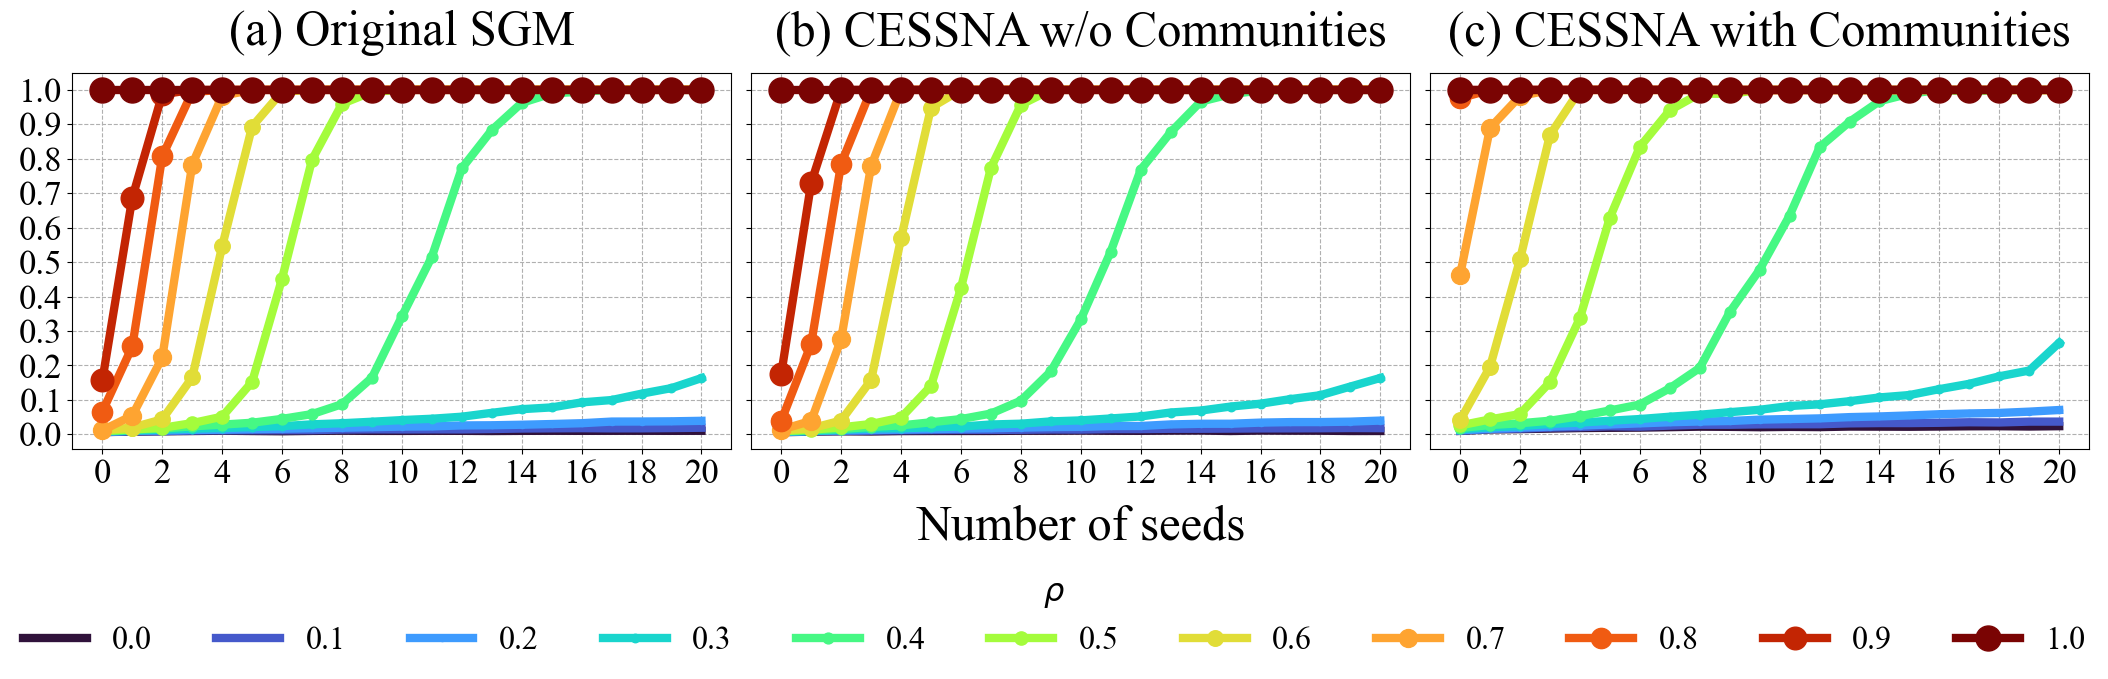

In [9]:
# Figure 1: color-friendly version

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import ListedColormap
from matplotlib.font_manager import FontProperties


font_prop = FontProperties(family='Times New Roman', size=23)
title_font = {"fontname": "Times New Roman"}


list1 = reshaped_SGM
list2 = reshaped_without_c
list3 = [[0.010177777777777777, 0.014470457079152732, 0.015302013422818792, 0.016790123456790127, 0.01835585585585586, 0.01911864406779661, 0.019637188208616776, 0.020978384527872585, 0.0223972602739726, 0.021901489117983963, 0.020850574712643677, 0.021753171856978087, 0.021157407407407406, 0.022694541231126596, 0.022494172494172494, 0.022152046783625732, 0.02279342723004695, 0.023510011778563017, 0.023735224586288416, 0.02284697508896797, 0.023857142857142855], [0.01111111111111111, 0.01520624303232999, 0.016711409395973154, 0.019842873176206505, 0.021148648648648648, 0.02352542372881356, 0.022494331065759633, 0.025437997724687144, 0.027990867579908672, 0.027972508591065287, 0.029057471264367814, 0.02934256055363323, 0.02944444444444444, 0.03198606271777004, 0.032867132867132866, 0.0328187134502924, 0.03368544600938967, 0.0352414605418139, 0.03458628841607565, 0.037058125741399765, 0.03707142857142857], [0.011711111111111111, 0.01612040133779264, 0.019664429530201342, 0.022514029180695845, 0.025450450450450454, 0.028768361581920903, 0.03197278911564626, 0.03526734926052332, 0.03737442922374429, 0.038808705612829314, 0.042781609195402304, 0.044567474048442905, 0.046435185185185184, 0.05010452961672474, 0.05207459207459208, 0.054994152046783616, 0.05849765258215962, 0.06075382803297998, 0.06224586288416075, 0.06600237247924082, 0.07071428571428572], [0.0148, 0.020891861761426978, 0.023937360178970916, 0.03041526374859708, 0.03414414414414415, 0.03961581920903955, 0.044557823129251696, 0.05130830489192264, 0.05705479452054794, 0.06442153493699884, 0.07144827586206896, 0.08232987312572088, 0.08719907407407408, 0.09630662020905924, 0.10722610722610722, 0.11422222222222222, 0.1313615023474178, 0.14680800942285038, 0.16858156028368795, 0.18533807829181492, 0.2660238095238095], [0.018511111111111114, 0.027090301003344485, 0.03223713646532438, 0.039708193041526375, 0.052995495495495495, 0.06946892655367232, 0.08662131519274377, 0.1339476678043231, 0.19303652968036528, 0.3545704467353952, 0.4782068965517241, 0.6353402537485583, 0.8334027777777777, 0.9072706155632985, 0.9671095571095571, 0.9890292397660819, 0.9995774647887323, 0.9951236749116606, 0.9993144208037825, 0.9995492289442467, 0.9996666666666668], [0.025955555555555555, 0.04345596432552955, 0.05899328859060403, 0.15160493827160493, 0.337545045045045, 0.6292203389830509, 0.8345124716553288, 0.9408191126279863, 0.9892922374429225, 0.9883390607101948, 0.999816091954023, 0.9995617070357555, 0.9997685185185184, 0.9998373983739839, 0.9995104895104896, 0.9997192982456139, 0.9997183098591548, 0.9997644287396936, 0.9995035460992907, 0.9998102016607354, 0.9993095238095239], [0.040488888888888894, 0.19616499442586396, 0.5076733780760626, 0.869090909090909, 0.9999099099099099, 0.9998644067796609, 0.9997732426303856, 0.9998407281001137, 0.9999543378995432, 0.9992439862542957, 0.9999080459770114, 0.9996309111880047, 0.9995833333333334, 0.9994889663182346, 0.9997668997668999, 0.9997426900584795, 0.9998122065727701, 0.9999057714958774, 1.0, 1.0, 1.0], [0.4626222222222223, 0.8896098104793757, 0.9818120805369129, 0.9999551066217733, 0.9997297297297297, 0.999909604519774, 0.999591836734694, 0.9995221843003412, 0.9995433789954338, 0.999839633447881, 0.999816091954023, 0.9999538638985007, 1.0, 1.0, 1.0, 1.0, 0.9997417840375586, 0.9998822143698468, 0.9996690307328606, 0.9996204033214708, 0.9991904761904762], [0.9760444444444445, 0.9998216276477145, 0.9996420581655482, 0.999685746352413, 0.9995495495495494, 0.999909604519774, 1.0, 1.0, 1.0, 1.0, 1.0, 0.9999538638985007, 0.9999305555555557, 0.9994889663182346, 0.9992074592074592, 0.999017543859649, 0.9994600938967136, 0.9993404004711425, 0.9995271867612293, 0.9995255041518385, 0.9994285714285714], [0.9999111111111112, 0.9996655518394649, 0.999910514541387, 1.0, 1.0, 0.9998870056497176, 0.9999546485260771, 0.9998179749715587, 0.9995890410958903, 0.9990378006872853, 0.9988045977011495, 0.9992156862745097, 0.9991203703703703, 0.9994425087108015, 0.9996270396270397, 0.999766081871345, 0.9998122065727701, 0.9998586572438164, 0.9999527186761228, 1.0, 1.0], [0.9995111111111111, 0.9995986622073578, 0.9997315436241612, 0.999685746352413, 0.9999549549549549, 1.0, 0.9999546485260771, 1.0, 0.9999543378995432, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0]]



rho_values = np.arange(0, 1.01, 0.1)
n_colors = len(rho_values)


min_ms, max_ms = 1, 18
marker_sizes = min_ms + (max_ms - min_ms) * rho_values

cmap = plt.get_cmap('turbo')
colors = cmap(np.linspace(0, 1, n_colors))
discrete_turbo = ListedColormap(colors)


fig, axs = plt.subplots(1, 3, figsize=(21, 6), sharey=True)
titles = ["(a) Original SGM", "(b) CESSNA w/o Communities", "(c) CESSNA with Communities"]

legend_handles = []
legend_labels = []

for idx, data_list in enumerate([list1, list2, list3]):
    ax = axs[idx]
    ax.yaxis.set_tick_params(labelleft=(idx == 0))

    for label in ax.get_xticklabels():
        label.set_fontname('Times New Roman')
    for label in ax.get_yticklabels():
        label.set_fontname('Times New Roman')

    # get maximum length in this panel (for ticks)
    max_len = max(len(np.asarray(row).ravel()) for row in data_list)

    for i, y_values in enumerate(data_list):
        y = np.asarray(y_values).ravel()
        x = np.arange(len(y))

        color = discrete_turbo(i / (n_colors - 1))
        ms = marker_sizes[i]

        line, = ax.plot(
            x, y,
            label=f'{rho_values[i]:.1f}',
            color=color,
            marker='o',
            markersize=ms,
            linewidth=6,
        )

        if idx == 0:

            legend_handles.append(line)
            legend_labels.append(f'{rho_values[i]:.1f}')

    ax.set_title(titles[idx], **title_font, fontsize=35, pad=20)

    if idx == 1:
        ax.set_xlabel('Number of seeds', **title_font, fontsize=35, labelpad=10)

    ax.set_xticks(np.arange(0, max_len, 2))
    ax.tick_params(axis='x', labelsize=25)

    ax.set_yticks(np.arange(0, 1.1, 0.1))
    ax.tick_params(axis='y', labelsize=25)

    ax.grid(True, linestyle='--')

plt.subplots_adjust(wspace=0.08)

fig.legend(
    legend_handles,
    legend_labels,
    title=r'$\rho$',
    loc='lower center',
    bbox_to_anchor=(0.5, -0.15),
    ncol=n_colors,
    frameon=False,
    prop=font_prop,
    title_fontproperties=font_prop
)

plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.savefig('SGM.png', dpi=600, bbox_inches='tight')
plt.show()

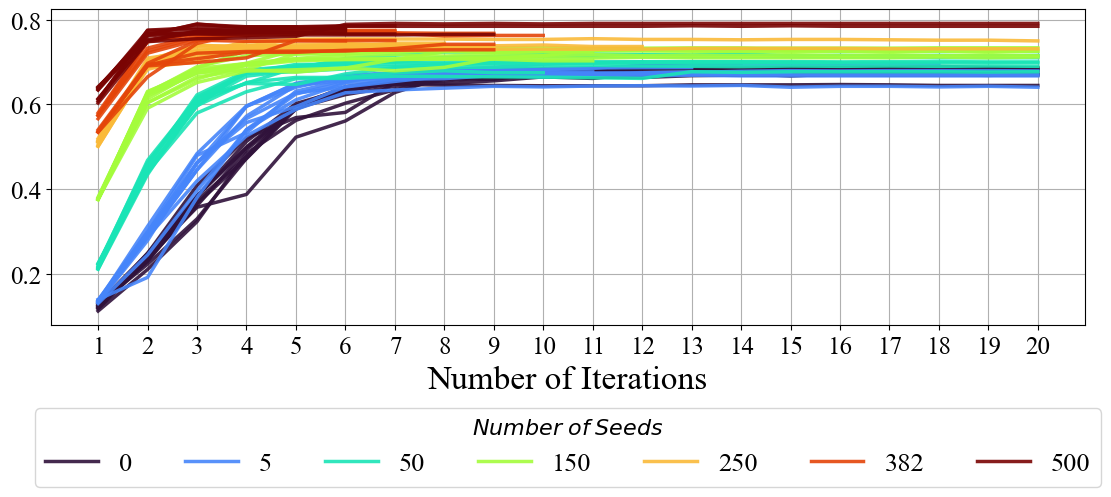

In [11]:
# Figure 2

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import ListedColormap
from matplotlib.font_manager import FontProperties

arrs =[[[np.float64(0.12011577424023155), np.float64(0.24819102749638206), np.float64(0.38205499276411), np.float64(0.5123010130246021), np.float64(0.6020260492040521), np.float64(0.6353111432706223), np.float64(0.6562952243125905), np.float64(0.6693198263386396), np.float64(0.6671490593342981), np.float64(0.6693198263386396), np.float64(0.6642547033285094), np.float64(0.6642547033285094), np.float64(0.6722141823444283), np.float64(0.6751085383502171), np.float64(0.678726483357453), np.float64(0.6780028943560058), np.float64(0.6780028943560058), np.float64(0.6772793053545586), np.float64(0.6751085383502171), np.float64(0.6801736613603473)], [np.float64(0.1287988422575977), np.float64(0.24746743849493488), np.float64(0.4081041968162084), np.float64(0.5209840810419681), np.float64(0.5687409551374819), np.float64(0.581041968162084), np.float64(0.6512301013024602), np.float64(0.6606367583212736), np.float64(0.6591895803183792), np.float64(0.6736613603473227), np.float64(0.683068017366136), np.float64(0.6917510853835022), np.float64(0.6924746743849494), np.float64(0.6924746743849494)], [np.float64(0.11649782923299566), np.float64(0.23154848046309695), np.float64(0.3835021707670043), np.float64(0.4992764109985528), np.float64(0.5962373371924746), np.float64(0.6324167872648335), np.float64(0.6490593342981187), np.float64(0.6555716353111433), np.float64(0.6642547033285094), np.float64(0.6649782923299565), np.float64(0.6613603473227206), np.float64(0.6729377713458755), np.float64(0.6693198263386396), np.float64(0.6693198263386396), np.float64(0.6693198263386396), np.float64(0.6693198263386396), np.float64(0.6693198263386396), np.float64(0.6693198263386396), np.float64(0.6700434153400868), np.float64(0.6693198263386396)], [np.float64(0.12083936324167872), np.float64(0.23733719247467439), np.float64(0.35672937771345875), np.float64(0.3871201157742402), np.float64(0.5224312590448625), np.float64(0.5607814761215629), np.float64(0.6280752532561505), np.float64(0.6642547033285094), np.float64(0.6837916063675832), np.float64(0.6845151953690304), np.float64(0.6852387843704776), np.float64(0.6881331403762663), np.float64(0.691027496382055), np.float64(0.6881331403762663), np.float64(0.6888567293777135), np.float64(0.6903039073806078), np.float64(0.6881331403762663), np.float64(0.6895803183791607), np.float64(0.6874095513748191), np.float64(0.6866859623733719)], [np.float64(0.12156295224312591), np.float64(0.23227206946454415), np.float64(0.36034732272069464), np.float64(0.4927641099855282), np.float64(0.5890014471780028), np.float64(0.6309696092619392), np.float64(0.6570188133140377), np.float64(0.6635311143270622), np.float64(0.6729377713458755), np.float64(0.6751085383502171), np.float64(0.6736613603473227), np.float64(0.6845151953690304), np.float64(0.6845151953690304), np.float64(0.6852387843704776), np.float64(0.6823444283646889), np.float64(0.6859623733719248), np.float64(0.6845151953690304), np.float64(0.6859623733719248), np.float64(0.6845151953690304), np.float64(0.6845151953690304)], [np.float64(0.1251808972503618), np.float64(0.2337192474674385), np.float64(0.3827785817655572), np.float64(0.4971056439942113), np.float64(0.5911722141823444), np.float64(0.6230101302460203), np.float64(0.6425470332850941), np.float64(0.6591895803183792), np.float64(0.6685962373371924), np.float64(0.6657018813314037), np.float64(0.6823444283646889), np.float64(0.683068017366136), np.float64(0.6837916063675832), np.float64(0.6794500723589001), np.float64(0.683068017366136), np.float64(0.6808972503617945), np.float64(0.683068017366136), np.float64(0.6816208393632417), np.float64(0.683068017366136), np.float64(0.6823444283646889)], [np.float64(0.12373371924746744), np.float64(0.22865412445730826), np.float64(0.37264833574529665), np.float64(0.4768451519536903), np.float64(0.5962373371924746), np.float64(0.6418234442836469), np.float64(0.6577424023154848), np.float64(0.6635311143270622), np.float64(0.6736613603473227), np.float64(0.6736613603473227), np.float64(0.6722141823444283), np.float64(0.6751085383502171), np.float64(0.6729377713458755), np.float64(0.6729377713458755), np.float64(0.6671490593342981), np.float64(0.6722141823444283), np.float64(0.6693198263386396), np.float64(0.6700434153400868), np.float64(0.6685962373371924), np.float64(0.670767004341534)], [np.float64(0.11794500723589002), np.float64(0.23444283646888567), np.float64(0.3661360347322721), np.float64(0.4717800289435601), np.float64(0.5890014471780028), np.float64(0.6403762662807525), np.float64(0.6476121562952243), np.float64(0.6454413892908828), np.float64(0.6447178002894356), np.float64(0.6439942112879884), np.float64(0.6439942112879884), np.float64(0.6439942112879884), np.float64(0.64616497829233), np.float64(0.64616497829233), np.float64(0.64616497829233), np.float64(0.6468885672937771), np.float64(0.64616497829233), np.float64(0.6447178002894356), np.float64(0.6447178002894356), np.float64(0.6447178002894356)], [np.float64(0.12735166425470332), np.float64(0.22214182344428365), np.float64(0.329232995658466), np.float64(0.4725036179450072), np.float64(0.5926193921852387), np.float64(0.6331403762662807), np.float64(0.650506512301013), np.float64(0.6490593342981187), np.float64(0.6555716353111433), np.float64(0.6649782923299565), np.float64(0.6649782923299565), np.float64(0.6635311143270622), np.float64(0.6678726483357453), np.float64(0.6693198263386396), np.float64(0.6693198263386396), np.float64(0.670767004341534), np.float64(0.6722141823444283), np.float64(0.6736613603473227), np.float64(0.6736613603473227), np.float64(0.6736613603473227)], [np.float64(0.11143270622286541), np.float64(0.2098408104196816), np.float64(0.3227206946454414), np.float64(0.4840810419681621), np.float64(0.5622286541244573), np.float64(0.6027496382054993), np.float64(0.6345875542691751), np.float64(0.6599131693198264), np.float64(0.6736613603473227), np.float64(0.6751085383502171), np.float64(0.6780028943560058), np.float64(0.6751085383502171), np.float64(0.6751085383502171), np.float64(0.6772793053545586), np.float64(0.6816208393632417), np.float64(0.6816208393632417), np.float64(0.6816208393632417), np.float64(0.6816208393632417)]], [[np.float64(0.13507625272331156), np.float64(0.28903413217138707), np.float64(0.44517066085693535), np.float64(0.5722585330428468), np.float64(0.644880174291939), np.float64(0.6564996368917938), np.float64(0.6695715323166304), np.float64(0.6652142338416849), np.float64(0.6673928830791576), np.float64(0.6652142338416849), np.float64(0.6702977487291213), np.float64(0.6673928830791576), np.float64(0.6688453159041394), np.float64(0.6673928830791576), np.float64(0.6673928830791576), np.float64(0.6673928830791576), np.float64(0.6673928830791576), np.float64(0.6673928830791576), np.float64(0.6673928830791576), np.float64(0.6673928830791576)], [np.float64(0.13144517066085692), np.float64(0.27814088598402326), np.float64(0.4625998547567175), np.float64(0.5664488017429193), np.float64(0.6267247639796659), np.float64(0.6412490922294843), np.float64(0.654320987654321), np.float64(0.6666666666666666), np.float64(0.6768336964415396), np.float64(0.6768336964415396), np.float64(0.6768336964415396)], [np.float64(0.1336238198983297), np.float64(0.289760348583878), np.float64(0.46042120551924476), np.float64(0.5954974582425563), np.float64(0.6405228758169934), np.float64(0.6659404502541757), np.float64(0.6724763979665941), np.float64(0.681917211328976), np.float64(0.6877269426289034), np.float64(0.6949891067538126), np.float64(0.6993464052287581), np.float64(0.6993464052287581)], [np.float64(0.13725490196078433), np.float64(0.29920116194626), np.float64(0.46187363834422657), np.float64(0.5570079883805374), np.float64(0.5947712418300654), np.float64(0.6419753086419753), np.float64(0.6594045025417574), np.float64(0.6608569353667393), np.float64(0.6681190994916485), np.float64(0.6659404502541757), np.float64(0.6681190994916485), np.float64(0.6739288307915758), np.float64(0.6739288307915758), np.float64(0.6753812636165577), np.float64(0.6753812636165577)], [np.float64(0.13725490196078433), np.float64(0.28685548293391433), np.float64(0.44517066085693535), np.float64(0.5954974582425563), np.float64(0.6499636891793754), np.float64(0.6681190994916485), np.float64(0.6753812636165577), np.float64(0.6739288307915758), np.float64(0.6746550472040668), np.float64(0.6746550472040668), np.float64(0.6717501815541032), np.float64(0.6717501815541032), np.float64(0.6710239651416122), np.float64(0.6710239651416122), np.float64(0.6710239651416122), np.float64(0.6702977487291213), np.float64(0.6702977487291213), np.float64(0.6702977487291213), np.float64(0.6702977487291213), np.float64(0.6702977487291213)], [np.float64(0.13435003631082063), np.float64(0.29774872912127814), np.float64(0.4793028322440087), np.float64(0.533042846768337), np.float64(0.6310820624546115), np.float64(0.6572258533042846), np.float64(0.663761801016703), np.float64(0.673202614379085), np.float64(0.6724763979665941), np.float64(0.6739288307915758), np.float64(0.6739288307915758), np.float64(0.6746550472040668), np.float64(0.6768336964415396), np.float64(0.6768336964415396)], [np.float64(0.1336238198983297), np.float64(0.3115468409586057), np.float64(0.48366013071895425), np.float64(0.5962236746550472), np.float64(0.6485112563543937), np.float64(0.6615831517792302), np.float64(0.6652142338416849), np.float64(0.6710239651416122), np.float64(0.6702977487291213), np.float64(0.6695715323166304), np.float64(0.673202614379085), np.float64(0.673202614379085), np.float64(0.6753812636165577), np.float64(0.6782861292665214), np.float64(0.6797385620915033), np.float64(0.6790123456790124), np.float64(0.6797385620915033), np.float64(0.6797385620915033), np.float64(0.6797385620915033), np.float64(0.6790123456790124)], [np.float64(0.13217138707334786), np.float64(0.2861292665214234), np.float64(0.4190268700072622), np.float64(0.5257806826434277), np.float64(0.5882352941176471), np.float64(0.6274509803921569), np.float64(0.6339869281045751), np.float64(0.6383442265795207), np.float64(0.6427015250544662), np.float64(0.6412490922294843), np.float64(0.6434277414669571), np.float64(0.6441539578794481), np.float64(0.6434277414669571), np.float64(0.644880174291939), np.float64(0.6405228758169934), np.float64(0.6427015250544662), np.float64(0.6427015250544662), np.float64(0.6412490922294843), np.float64(0.6427015250544662), np.float64(0.6405228758169934)], [np.float64(0.12926652142338416), np.float64(0.2440087145969499), np.float64(0.39578794480755264), np.float64(0.5403050108932462), np.float64(0.6107480029048656), np.float64(0.6506899055918663), np.float64(0.6615831517792302), np.float64(0.6739288307915758), np.float64(0.6804647785039942), np.float64(0.681917211328976), np.float64(0.6862745098039216), np.float64(0.6870007262164125), np.float64(0.6870007262164125)], [np.float64(0.13870733478576616), np.float64(0.19099491648511258), np.float64(0.37981118373275236), np.float64(0.5403050108932462), np.float64(0.6245461147421931), np.float64(0.6521423384168482), np.float64(0.6753812636165577), np.float64(0.6833696441539578), np.float64(0.6840958605664488), np.float64(0.6840958605664488), np.float64(0.6855482933914306), np.float64(0.6928104575163399), np.float64(0.6928104575163399), np.float64(0.6935366739288308), np.float64(0.6949891067538126), np.float64(0.6949891067538126), np.float64(0.6964415395787945), np.float64(0.6964415395787945)]], [[np.float64(0.21396396396396397), np.float64(0.4391891891891892), np.float64(0.5795795795795796), np.float64(0.6298798798798799), np.float64(0.6606606606606606), np.float64(0.6614114114114115), np.float64(0.6666666666666666), np.float64(0.6659159159159159), np.float64(0.6651651651651652), np.float64(0.6644144144144144), np.float64(0.6629129129129129), np.float64(0.6614114114114115), np.float64(0.6771771771771772), np.float64(0.6756756756756757), np.float64(0.6771771771771772), np.float64(0.6771771771771772), np.float64(0.6771771771771772), np.float64(0.6771771771771772), np.float64(0.6764264264264265), np.float64(0.6771771771771772)], [np.float64(0.22297297297297297), np.float64(0.44144144144144143), np.float64(0.5960960960960962), np.float64(0.6816816816816816), np.float64(0.6906906906906907), np.float64(0.6981981981981982), np.float64(0.7004504504504504), np.float64(0.7004504504504504), np.float64(0.7027027027027027), np.float64(0.7012012012012012), np.float64(0.7004504504504504), np.float64(0.7004504504504504), np.float64(0.7012012012012012), np.float64(0.7012012012012012), np.float64(0.7012012012012012), np.float64(0.7004504504504504), np.float64(0.7012012012012012), np.float64(0.7012012012012012), np.float64(0.7004504504504504), np.float64(0.7004504504504504)], [np.float64(0.21246246246246248), np.float64(0.4602102102102102), np.float64(0.6156156156156156), np.float64(0.6493993993993994), np.float64(0.6471471471471472), np.float64(0.6719219219219219), np.float64(0.6869369369369369), np.float64(0.6876876876876877), np.float64(0.6876876876876877), np.float64(0.6906906906906907), np.float64(0.6921921921921922), np.float64(0.6906906906906907), np.float64(0.68993993993994), np.float64(0.6891891891891891), np.float64(0.6906906906906907), np.float64(0.68993993993994), np.float64(0.6906906906906907), np.float64(0.68993993993994), np.float64(0.6906906906906907), np.float64(0.68993993993994)], [np.float64(0.21021021021021022), np.float64(0.4339339339339339), np.float64(0.6066066066066066), np.float64(0.6501501501501501), np.float64(0.6869369369369369), np.float64(0.6929429429429429), np.float64(0.6951951951951952), np.float64(0.6959459459459459), np.float64(0.6974474474474475), np.float64(0.6981981981981982), np.float64(0.6974474474474475), np.float64(0.7004504504504504), np.float64(0.6974474474474475), np.float64(0.6974474474474475), np.float64(0.698948948948949), np.float64(0.698948948948949)], [np.float64(0.21846846846846846), np.float64(0.4677177177177177), np.float64(0.6133633633633634), np.float64(0.6734234234234234), np.float64(0.6771771771771772), np.float64(0.683933933933934), np.float64(0.6891891891891891), np.float64(0.6944444444444444), np.float64(0.6951951951951952), np.float64(0.6974474474474475), np.float64(0.698948948948949), np.float64(0.6996996996996997), np.float64(0.7004504504504504), np.float64(0.7004504504504504), np.float64(0.698948948948949), np.float64(0.6981981981981982), np.float64(0.6981981981981982), np.float64(0.6981981981981982), np.float64(0.6981981981981982), np.float64(0.6981981981981982)], [np.float64(0.21546546546546547), np.float64(0.4451951951951952), np.float64(0.5968468468468469), np.float64(0.6516516516516516), np.float64(0.6636636636636637), np.float64(0.6636636636636637), np.float64(0.674924924924925), np.float64(0.6794294294294294), np.float64(0.674924924924925), np.float64(0.674924924924925)], [np.float64(0.2222222222222222), np.float64(0.4624624624624625), np.float64(0.6051051051051051), np.float64(0.6666666666666666), np.float64(0.6801801801801802), np.float64(0.698948948948949), np.float64(0.7004504504504504), np.float64(0.7102102102102102), np.float64(0.7132132132132132), np.float64(0.7147147147147147), np.float64(0.7132132132132132), np.float64(0.7147147147147147), np.float64(0.7147147147147147), np.float64(0.7162162162162162), np.float64(0.713963963963964), np.float64(0.7154654654654654), np.float64(0.713963963963964), np.float64(0.7154654654654654), np.float64(0.713963963963964), np.float64(0.7154654654654654)], [np.float64(0.21096096096096095), np.float64(0.4466966966966967), np.float64(0.6171171171171171), np.float64(0.674924924924925), np.float64(0.6944444444444444), np.float64(0.6951951951951952), np.float64(0.7042042042042042), np.float64(0.7094594594594594), np.float64(0.7124624624624625), np.float64(0.7124624624624625), np.float64(0.7124624624624625), np.float64(0.7124624624624625), np.float64(0.7124624624624625), np.float64(0.7124624624624625), np.float64(0.7124624624624625), np.float64(0.7117117117117117), np.float64(0.7117117117117117), np.float64(0.7102102102102102), np.float64(0.7102102102102102), np.float64(0.7102102102102102)], [np.float64(0.22447447447447447), np.float64(0.43843843843843844), np.float64(0.6021021021021021), np.float64(0.6779279279279279), np.float64(0.6891891891891891), np.float64(0.7019519519519519), np.float64(0.704954954954955), np.float64(0.710960960960961), np.float64(0.7132132132132132), np.float64(0.7162162162162162), np.float64(0.7147147147147147), np.float64(0.7162162162162162), np.float64(0.7154654654654654), np.float64(0.7162162162162162), np.float64(0.7147147147147147), np.float64(0.7154654654654654), np.float64(0.7147147147147147), np.float64(0.7154654654654654), np.float64(0.7147147147147147), np.float64(0.7154654654654654)], [np.float64(0.2147147147147147), np.float64(0.45570570570570573), np.float64(0.6223723723723724), np.float64(0.6786786786786787), np.float64(0.683933933933934), np.float64(0.7087087087087087), np.float64(0.7162162162162162), np.float64(0.7237237237237237), np.float64(0.7237237237237237), np.float64(0.7184684684684685), np.float64(0.7192192192192193), np.float64(0.7177177177177178), np.float64(0.7169669669669669), np.float64(0.7192192192192193), np.float64(0.7147147147147147), np.float64(0.7147147147147147)]], [[np.float64(0.3782467532467532), np.float64(0.6038961038961039), np.float64(0.6647727272727273), np.float64(0.6818181818181818), np.float64(0.6761363636363636), np.float64(0.6858766233766234), np.float64(0.6793831168831169), np.float64(0.6875), np.float64(0.7086038961038961), np.float64(0.7150974025974026), np.float64(0.7280844155844156), np.float64(0.7313311688311688), np.float64(0.7329545454545454), np.float64(0.7329545454545454), np.float64(0.7280844155844156), np.float64(0.7280844155844156)], [np.float64(0.3782467532467532), np.float64(0.6233766233766234), np.float64(0.6858766233766234), np.float64(0.7272727272727273), np.float64(0.7297077922077922), np.float64(0.734577922077922), np.float64(0.7313311688311688), np.float64(0.7248376623376623), np.float64(0.7272727272727273), np.float64(0.726461038961039), np.float64(0.7272727272727273), np.float64(0.7272727272727273), np.float64(0.726461038961039), np.float64(0.7248376623376623), np.float64(0.7248376623376623), np.float64(0.7248376623376623), np.float64(0.7248376623376623), np.float64(0.7256493506493507), np.float64(0.7256493506493507), np.float64(0.7256493506493507)], [np.float64(0.375), np.float64(0.6306818181818182), np.float64(0.6777597402597403), np.float64(0.6972402597402597), np.float64(0.7288961038961039), np.float64(0.7288961038961039), np.float64(0.7313311688311688), np.float64(0.7313311688311688), np.float64(0.7337662337662337), np.float64(0.7337662337662337), np.float64(0.7329545454545454), np.float64(0.7329545454545454), np.float64(0.7329545454545454), np.float64(0.7329545454545454), np.float64(0.7329545454545454), np.float64(0.7329545454545454), np.float64(0.7329545454545454), np.float64(0.7337662337662337), np.float64(0.7337662337662337), np.float64(0.7337662337662337)], [np.float64(0.3758116883116883), np.float64(0.5909090909090909), np.float64(0.6517857142857143), np.float64(0.6785714285714286), np.float64(0.6818181818181818), np.float64(0.6858766233766234), np.float64(0.7061688311688312), np.float64(0.7248376623376623), np.float64(0.7224025974025974), np.float64(0.724025974025974), np.float64(0.724025974025974)], [np.float64(0.3758116883116883), np.float64(0.6266233766233766), np.float64(0.6891233766233766), np.float64(0.7150974025974026), np.float64(0.7191558441558441), np.float64(0.7248376623376623), np.float64(0.7248376623376623), np.float64(0.726461038961039), np.float64(0.7248376623376623), np.float64(0.7256493506493507), np.float64(0.7272727272727273), np.float64(0.726461038961039), np.float64(0.7256493506493507), np.float64(0.7256493506493507), np.float64(0.726461038961039), np.float64(0.7256493506493507), np.float64(0.7256493506493507), np.float64(0.7256493506493507), np.float64(0.7256493506493507), np.float64(0.7256493506493507)], [np.float64(0.3758116883116883), np.float64(0.6038961038961039), np.float64(0.6599025974025974), np.float64(0.6931818181818182), np.float64(0.7061688311688312), np.float64(0.7061688311688312), np.float64(0.7061688311688312), np.float64(0.7077922077922078), np.float64(0.711038961038961), np.float64(0.7077922077922078), np.float64(0.7094155844155844), np.float64(0.711038961038961), np.float64(0.7102272727272727), np.float64(0.7102272727272727), np.float64(0.7102272727272727), np.float64(0.7102272727272727), np.float64(0.7102272727272727), np.float64(0.7118506493506493), np.float64(0.7102272727272727), np.float64(0.7118506493506493)], [np.float64(0.375), np.float64(0.6201298701298701), np.float64(0.6737012987012987), np.float64(0.6915584415584416), np.float64(0.702922077922078), np.float64(0.7061688311688312), np.float64(0.7061688311688312), np.float64(0.7069805194805194), np.float64(0.7069805194805194), np.float64(0.702922077922078), np.float64(0.702922077922078)], [np.float64(0.37743506493506496), np.float64(0.6290584415584416), np.float64(0.685064935064935), np.float64(0.6964285714285714), np.float64(0.7086038961038961), np.float64(0.7159090909090909), np.float64(0.7175324675324676), np.float64(0.7142857142857143), np.float64(0.7175324675324676), np.float64(0.7150974025974026), np.float64(0.7175324675324676), np.float64(0.7150974025974026), np.float64(0.7167207792207793), np.float64(0.7150974025974026), np.float64(0.7175324675324676), np.float64(0.7150974025974026), np.float64(0.7175324675324676), np.float64(0.7150974025974026), np.float64(0.7175324675324676), np.float64(0.7150974025974026)], [np.float64(0.3806818181818182), np.float64(0.6241883116883117), np.float64(0.674512987012987), np.float64(0.6826298701298701), np.float64(0.7191558441558441), np.float64(0.7191558441558441), np.float64(0.7256493506493507), np.float64(0.7272727272727273), np.float64(0.7256493506493507), np.float64(0.7280844155844156), np.float64(0.7297077922077922), np.float64(0.7297077922077922)], [np.float64(0.375), np.float64(0.6128246753246753), np.float64(0.6785714285714286), np.float64(0.6956168831168831), np.float64(0.7061688311688312), np.float64(0.7077922077922078), np.float64(0.7077922077922078), np.float64(0.7077922077922078), np.float64(0.7077922077922078)]], [[np.float64(0.5123674911660777), np.float64(0.7049469964664311), np.float64(0.7385159010600707), np.float64(0.7376325088339223), np.float64(0.7535335689045937), np.float64(0.7535335689045937), np.float64(0.7535335689045937)], [np.float64(0.5008833922261484), np.float64(0.6881625441696113), np.float64(0.700530035335689), np.float64(0.734982332155477), np.float64(0.7367491166077739), np.float64(0.7367491166077739), np.float64(0.7446996466431095), np.float64(0.7446996466431095)], [np.float64(0.5114840989399293), np.float64(0.6828621908127208), np.float64(0.7102473498233216), np.float64(0.734982332155477), np.float64(0.734982332155477), np.float64(0.7376325088339223), np.float64(0.734982332155477), np.float64(0.7323321554770318), np.float64(0.7323321554770318)], [np.float64(0.5123674911660777), np.float64(0.7022968197879859), np.float64(0.7217314487632509), np.float64(0.7482332155477032), np.float64(0.7535335689045937), np.float64(0.7544169611307421), np.float64(0.7544169611307421), np.float64(0.7544169611307421), np.float64(0.7535335689045937), np.float64(0.7535335689045937), np.float64(0.7553003533568905), np.float64(0.7535335689045937), np.float64(0.7535335689045937), np.float64(0.7526501766784452), np.float64(0.7535335689045937), np.float64(0.7535335689045937), np.float64(0.7526501766784452), np.float64(0.7517667844522968), np.float64(0.7517667844522968), np.float64(0.75)], [np.float64(0.5044169611307421), np.float64(0.6925795053003534), np.float64(0.7402826855123675), np.float64(0.734982332155477), np.float64(0.741166077738516), np.float64(0.7438162544169611), np.float64(0.7402826855123675), np.float64(0.7402826855123675)], [np.float64(0.519434628975265), np.float64(0.7093639575971732), np.float64(0.726148409893993), np.float64(0.7332155477031802), np.float64(0.730565371024735), np.float64(0.7332155477031802), np.float64(0.7332155477031802)], [np.float64(0.5008833922261484), np.float64(0.6890459363957597), np.float64(0.7173144876325088), np.float64(0.734982332155477), np.float64(0.734982332155477), np.float64(0.7367491166077739), np.float64(0.7376325088339223), np.float64(0.7376325088339223), np.float64(0.7385159010600707), np.float64(0.7402826855123675), np.float64(0.7367491166077739), np.float64(0.7367491166077739)], [np.float64(0.5123674911660777), np.float64(0.6943462897526502), np.float64(0.7252650176678446), np.float64(0.7279151943462897), np.float64(0.7279151943462897), np.float64(0.7340989399293286), np.float64(0.734982332155477), np.float64(0.7332155477031802), np.float64(0.730565371024735), np.float64(0.730565371024735), np.float64(0.730565371024735), np.float64(0.730565371024735), np.float64(0.7323321554770318), np.float64(0.7323321554770318), np.float64(0.7323321554770318), np.float64(0.7323321554770318), np.float64(0.7314487632508834), np.float64(0.7314487632508834), np.float64(0.7314487632508834), np.float64(0.7314487632508834)], [np.float64(0.5097173144876325), np.float64(0.6925795053003534), np.float64(0.726148409893993), np.float64(0.7402826855123675), np.float64(0.7367491166077739), np.float64(0.7420494699646644), np.float64(0.7420494699646644)], [np.float64(0.5159010600706714), np.float64(0.7022968197879859), np.float64(0.7332155477031802), np.float64(0.7332155477031802), np.float64(0.7332155477031802), np.float64(0.7314487632508834), np.float64(0.7332155477031802), np.float64(0.7332155477031802), np.float64(0.7332155477031802)]], [[np.float64(0.574), np.float64(0.726), np.float64(0.758), np.float64(0.771), np.float64(0.774), np.float64(0.775), np.float64(0.775)], [np.float64(0.54), np.float64(0.697), np.float64(0.75), np.float64(0.769), np.float64(0.769)], [np.float64(0.535), np.float64(0.694), np.float64(0.708), np.float64(0.723), np.float64(0.723), np.float64(0.728), np.float64(0.728), np.float64(0.729), np.float64(0.729)], [np.float64(0.58), np.float64(0.748), np.float64(0.769), np.float64(0.767), np.float64(0.767), np.float64(0.769), np.float64(0.769), np.float64(0.768), np.float64(0.768)], [np.float64(0.574), np.float64(0.749), np.float64(0.767), np.float64(0.77), np.float64(0.776), np.float64(0.776)], [np.float64(0.574), np.float64(0.733), np.float64(0.762), np.float64(0.762), np.float64(0.774), np.float64(0.773), np.float64(0.773)], [np.float64(0.535), np.float64(0.691), np.float64(0.699), np.float64(0.71), np.float64(0.751), np.float64(0.751), np.float64(0.751)], [np.float64(0.534), np.float64(0.665), np.float64(0.744), np.float64(0.77), np.float64(0.771), np.float64(0.768), np.float64(0.768), np.float64(0.762), np.float64(0.763), np.float64(0.763)], [np.float64(0.566), np.float64(0.721), np.float64(0.752), np.float64(0.749), np.float64(0.75), np.float64(0.75)], [np.float64(0.536), np.float64(0.692), np.float64(0.721), np.float64(0.725), np.float64(0.726), np.float64(0.726), np.float64(0.732), np.float64(0.742), np.float64(0.742)]], [[np.float64(0.6394557823129252), np.float64(0.7664399092970522), np.float64(0.7664399092970522), np.float64(0.764172335600907), np.float64(0.764172335600907), np.float64(0.764172335600907), np.float64(0.764172335600907), np.float64(0.7653061224489796), np.float64(0.7653061224489796)], [np.float64(0.6133786848072562), np.float64(0.7505668934240363), np.float64(0.7732426303854876), np.float64(0.7766439909297053), np.float64(0.7789115646258503), np.float64(0.7789115646258503)], [np.float64(0.6031746031746031), np.float64(0.7482993197278912), np.float64(0.7551020408163265), np.float64(0.7573696145124716), np.float64(0.7607709750566893), np.float64(0.7891156462585034), np.float64(0.7913832199546486), np.float64(0.7902494331065759), np.float64(0.7913832199546486), np.float64(0.7902494331065759), np.float64(0.7913832199546486), np.float64(0.7913832199546486), np.float64(0.7913832199546486), np.float64(0.7913832199546486), np.float64(0.7913832199546486), np.float64(0.7913832199546486), np.float64(0.7913832199546486), np.float64(0.7913832199546486), np.float64(0.7913832199546486), np.float64(0.7913832199546486)], [np.float64(0.6337868480725624), np.float64(0.7630385487528345), np.float64(0.7902494331065759), np.float64(0.780045351473923), np.float64(0.782312925170068), np.float64(0.7845804988662132), np.float64(0.7845804988662132), np.float64(0.7845804988662132), np.float64(0.7845804988662132), np.float64(0.7845804988662132), np.float64(0.7845804988662132), np.float64(0.7845804988662132), np.float64(0.7857142857142857), np.float64(0.7845804988662132), np.float64(0.7857142857142857), np.float64(0.7845804988662132), np.float64(0.7845804988662132), np.float64(0.7845804988662132), np.float64(0.7845804988662132), np.float64(0.7845804988662132)], [np.float64(0.63718820861678), np.float64(0.7653061224489796), np.float64(0.7891156462585034), np.float64(0.7834467120181405), np.float64(0.7834467120181405), np.float64(0.7857142857142857), np.float64(0.7857142857142857)], [np.float64(0.6394557823129252), np.float64(0.7675736961451247), np.float64(0.7675736961451247), np.float64(0.7698412698412699), np.float64(0.7698412698412699), np.float64(0.7698412698412699)], [np.float64(0.6349206349206349), np.float64(0.7743764172335601), np.float64(0.7766439909297053), np.float64(0.7743764172335601), np.float64(0.7766439909297053), np.float64(0.7766439909297053)], [np.float64(0.6122448979591837), np.float64(0.7619047619047619), np.float64(0.7709750566893424), np.float64(0.7709750566893424)], [np.float64(0.6077097505668935), np.float64(0.7755102040816326), np.float64(0.7811791383219955), np.float64(0.7834467120181405), np.float64(0.7834467120181405)], [np.float64(0.6417233560090703), np.float64(0.7528344671201814), np.float64(0.7687074829931972), np.float64(0.7698412698412699), np.float64(0.7698412698412699), np.float64(0.7664399092970522), np.float64(0.7664399092970522)]]]


font_prop = FontProperties(size=19)

n_seeds = [0, 5, 50, 150, 250, 382, 500]
n_colors = len(arrs)

cmap = plt.get_cmap('turbo')
colors = cmap(np.linspace(0, 1, n_colors))
discrete_cmap = ListedColormap(colors)


fig, ax = plt.subplots(figsize=(12, 6))
title_fontsize = 16
label_fontsize = 18
tick_fontsize = 12

maxlen = max(max(len(row) for row in arr) for arr in arrs)

lines = []
labels = []

for i, arr in enumerate(arrs):
    color = discrete_cmap(i / (n_colors - 1))
    last_line = None
    for row in arr:
        xvals = np.arange(1, len(row) + 1)
        last_line, = ax.plot(
            xvals,
            row,
            color=color,
            alpha=0.9,
            linewidth=2.5,
            markersize=5,
            markevery=2,
        )
    lines.append(last_line)
    labels.append(f"{n_seeds[i]}")

ax.set_xlabel("Number of Iterations", fontsize=title_fontsize + 8)
ax.set_xticks(np.arange(1, maxlen + 1))
ax.tick_params(axis="x", labelsize=label_fontsize)
ax.tick_params(axis="y", labelsize=label_fontsize)
ax.grid(True)

ax.legend(
    lines,
    labels,
    fontsize=label_fontsize,
    loc="upper center",
    ncol=7,
    title=r"$Number\; of\; Seeds$",
    title_fontsize=title_fontsize,
    bbox_to_anchor=(0.5, -0.22),
    frameon=True,
    prop=font_prop,
)

plt.tight_layout(rect=[0, 0.1, 1, 1])
plt.show()

In [21]:
# Figure 3 data pre-processing:
import statistics
def read_and_average(filename):
    from collections import defaultdict

    averages = defaultdict(dict)
    with open(filename, 'r') as f:
        current_percentage = None
        current_seeds = None
        numbers = []

        for line in f:
            line = line.strip()
            if line.startswith('Current percentage of shuffling:'):
                if current_percentage is not None and current_seeds is not None and numbers:
                    avg = sum(numbers) / len(numbers)
                    averages[current_percentage][current_seeds] = avg
                current_percentage = int(line.split(':')[1].strip())
                current_seeds = None
                numbers = []
            elif line.startswith('Current number of seeds:'):
                if current_seeds is not None and numbers:
                    avg = sum(numbers) / len(numbers)
                    averages[current_percentage][current_seeds] = avg
                current_seeds = int(line.split(':')[1].strip())
                numbers = []
            elif line and not line.startswith('-'):
                for value in line.split():
                    try:
                        numbers.append(float(value))
                    except ValueError:
                        continue
        if current_percentage is not None and current_seeds is not None and numbers:
            avg = sum(numbers) / len(numbers)
            averages[current_percentage][current_seeds] = avg
    return dict(averages)

from collections import defaultdict
import math

def read_and_average_and_std(filename):
    averages = defaultdict(dict)
    with open(filename, 'r') as f:
        current_percentage = None
        current_seeds = None
        numbers = []

        for line in f:
            line = line.strip()
            if line.startswith('Current percentage of shuffling:'):
                if current_percentage is not None and current_seeds is not None and numbers:
                    avg = sum(numbers) / len(numbers)
                    variance = sum((x - avg)**2 for x in numbers) / len(numbers)
                    std = math.sqrt(variance)
                    averages[current_percentage][current_seeds] = [avg, std]
                current_percentage = int(line.split(':')[1].strip())
                current_seeds = None
                numbers = []
            elif line.startswith('Current number of seeds:'):
                if current_seeds is not None and numbers:
                    avg = sum(numbers) / len(numbers)
                    variance = sum((x - avg)**2 for x in numbers) / len(numbers)
                    std = math.sqrt(variance)
                    averages[current_percentage][current_seeds] = [avg, std]
                current_seeds = int(line.split(':')[1].strip())
                numbers = []
            elif line and not line.startswith('-'):
                for value in line.split():
                    try:
                        numbers.append(float(value))
                    except ValueError:
                        continue
        if current_percentage is not None and current_seeds is not None and numbers:
            avg = sum(numbers) / len(numbers)
            variance = sum((x - avg)**2 for x in numbers) / len(numbers)
            std = math.sqrt(variance)
            averages[current_percentage][current_seeds] = [avg, std]
    return dict(averages)
seed_values = {}

with open('worm_partition_labels.txt', 'r') as f:
    lines = f.readlines()

    i = 0
    while i < len(lines):
        line = lines[i].strip()
        if line.startswith("Current number of seeds"):
            seed_num = int(line.split()[-1])
            value_line = lines[i + 1].strip()
            try:
                value = float(value_line)
            except ValueError:
                i += 1
                continue
            if seed_num not in seed_values:
                seed_values[seed_num] = []
            seed_values[seed_num].append(value)
            i += 1
        i += 1

result_leiden = {}

for key, values in seed_values.items():
    avg = statistics.mean(values)
    std = np.std(values)
    result_leiden[key] = {'mean': avg, 'std': std}

print(result_leiden)

file_path = 'laiden_acc.txt'
seeds_values = {}

with open(file_path, 'r') as file:
    lines = file.readlines()

current_seeds = None
for i, line in enumerate(lines):
    line = line.strip()
    if line.startswith('Current number of seeds:'):
        current_seeds = int(line.split(':')[1].strip())
        if i + 1 < len(lines):
            value_line = lines[i + 1].strip()
            try:
                value = float(value_line)
                if current_seeds not in seeds_values:
                    seeds_values[current_seeds] = []
                seeds_values[current_seeds].append(value)
            except ValueError:
                pass

sorted_seeds_values = {k: seeds_values[k] for k in sorted(seeds_values)}

averages = []
std_devs = []

for seed_count in sorted(sorted_seeds_values.keys()):
    values = sorted_seeds_values[seed_count]
    averages.append(np.mean(values))
    std_devs.append(np.std(values))

averages_array = np.array(averages)
std_devs_array = np.array(std_devs)

new_third_plot_result = {0: [0.6819102749638205,
  np.float64(0.6748002904865651),
  np.float64(0.6907657657657658),
  np.float64(0.7166396103896105),
  np.float64(0.7421378091872791),
  np.float64(0.7537),
  np.float64(0.772108843537415)],
 10: [0.42228654124457304,
   np.float64(0.43725490196078437),
  np.float64(0.5182432432432431),
  np.float64(0.543262987012987),
  np.float64(0.5792402826855122),
  np.float64(0.6096),
  np.float64(0.6268707482993198)],
 20: [0.16266280752532564,
   np.float64(0.26049382716049385),
  np.float64(0.3973723723723724),
  np.float64(0.42248376623376627),
  np.float64(0.46007067137809193),
  np.float64(0.4864),
  np.float64(0.5230158730158729)],
 30: [0.06164978292329957,
   np.float64(0.14705882352941174),
  np.float64(0.21156156156156158),
  np.float64(0.3046266233766234),
  np.float64(0.32376325088339225),
  np.float64(0.369),
  np.float64(0.3826530612244898)],
 40: [0.05615050651230101,
   np.float64(0.027160493827160494),
  np.float64(0.07912912912912912),
  np.float64(0.13336038961038962),
  np.float64(0.1696996466431095),
  np.float64(0.21770000000000006),
  np.float64(0.24058956916099775)],
 50: [0.030824891461649784,
   np.float64(0.027814088598402325),
  np.float64(0.06328828828828828),
  np.float64(0.11647727272727273),
  np.float64(0.16863957597173146),
  np.float64(0.1798),
  np.float64(0.22086167800453516)],
 60: [0.017945007235890015,
   np.float64(0.017429193899782133),
  np.float64(0.027927927927927927),
  np.float64(0.04943181818181819),
  np.float64(0.0715547703180212),
  np.float64(0.09979999999999999),
  np.float64(0.12120181405895691)],
 70: [0.007670043415340086,
   np.float64(0.012854030501089325),
  np.float64(0.010735735735735736),
  np.float64(0.03084415584415584),
  np.float64(0.033833922261484094),
  np.float64(0.0617),
  np.float64(0.06723356009070294)],
 80: [0.004486251808972504,
   np.float64(0.005809731299927378),
  np.float64(0.006381381381381381),
  np.float64(0.005275974025974027),
  np.float64(0.011484098939929329),
  np.float64(0.0248),
  np.float64(0.029365079365079365)],
 90: [0.00593342981186686,
   np.float64(0.007044299201161947),
  np.float64(0.007432432432432433),
  np.float64(0.0055194805194805205),
  np.float64(0.007862190812720849),
  np.float64(0.0076999999999999985),
  np.float64(0.01337868480725624)],
 100: [0,0,0,0,0,0,0]}

percentages = [0,10,20,30,40,50,60,70,80,90,100]
seeds = [0,5,50,150,250,382,500]
averages = read_and_average('new_shuffling.txt')
avg_and_std = read_and_average_and_std('new_shuffling.txt')

result_2d_list = []

for p in percentages:
    row = []
    for s in seeds:
        row.append(averages.get(p, {}).get(s, None))
    result_2d_list.append(row)

std_2d_list = []

for p in percentages:
    row = []
    std_row = []
    for s in seeds:
        row.append(avg_and_std.get(p, {}).get(s, None))
        std_row.append(avg_and_std.get(p, {}).get(s, None)[1])
    std_2d_list.append(std_row)



{0: {'mean': 0.1605095993470315, 'std': np.float64(0.014666740628056356)}, 1: {'mean': 0.15841584158415842, 'std': np.float64(0.01619730260826545)}, 5: {'mean': 0.15624774156247742, 'std': np.float64(0.0156004468252925)}, 10: {'mean': 0.15937281460488056, 'std': np.float64(0.018396185444785974)}, 20: {'mean': 0.1734775794181735, 'std': np.float64(0.015852034306875887)}, 50: {'mean': 0.2249556833412599, 'std': np.float64(0.012942595629015272)}, 75: {'mean': 0.21384197243253736, 'std': np.float64(0.017919597374046713)}, 100: {'mean': 0.22119586260302007, 'std': np.float64(0.017154815144958504)}, 150: {'mean': 0.26847801059175685, 'std': np.float64(0.030460337413001668)}, 200: {'mean': 0.29565108409575136, 'std': np.float64(0.03743121825559113)}}


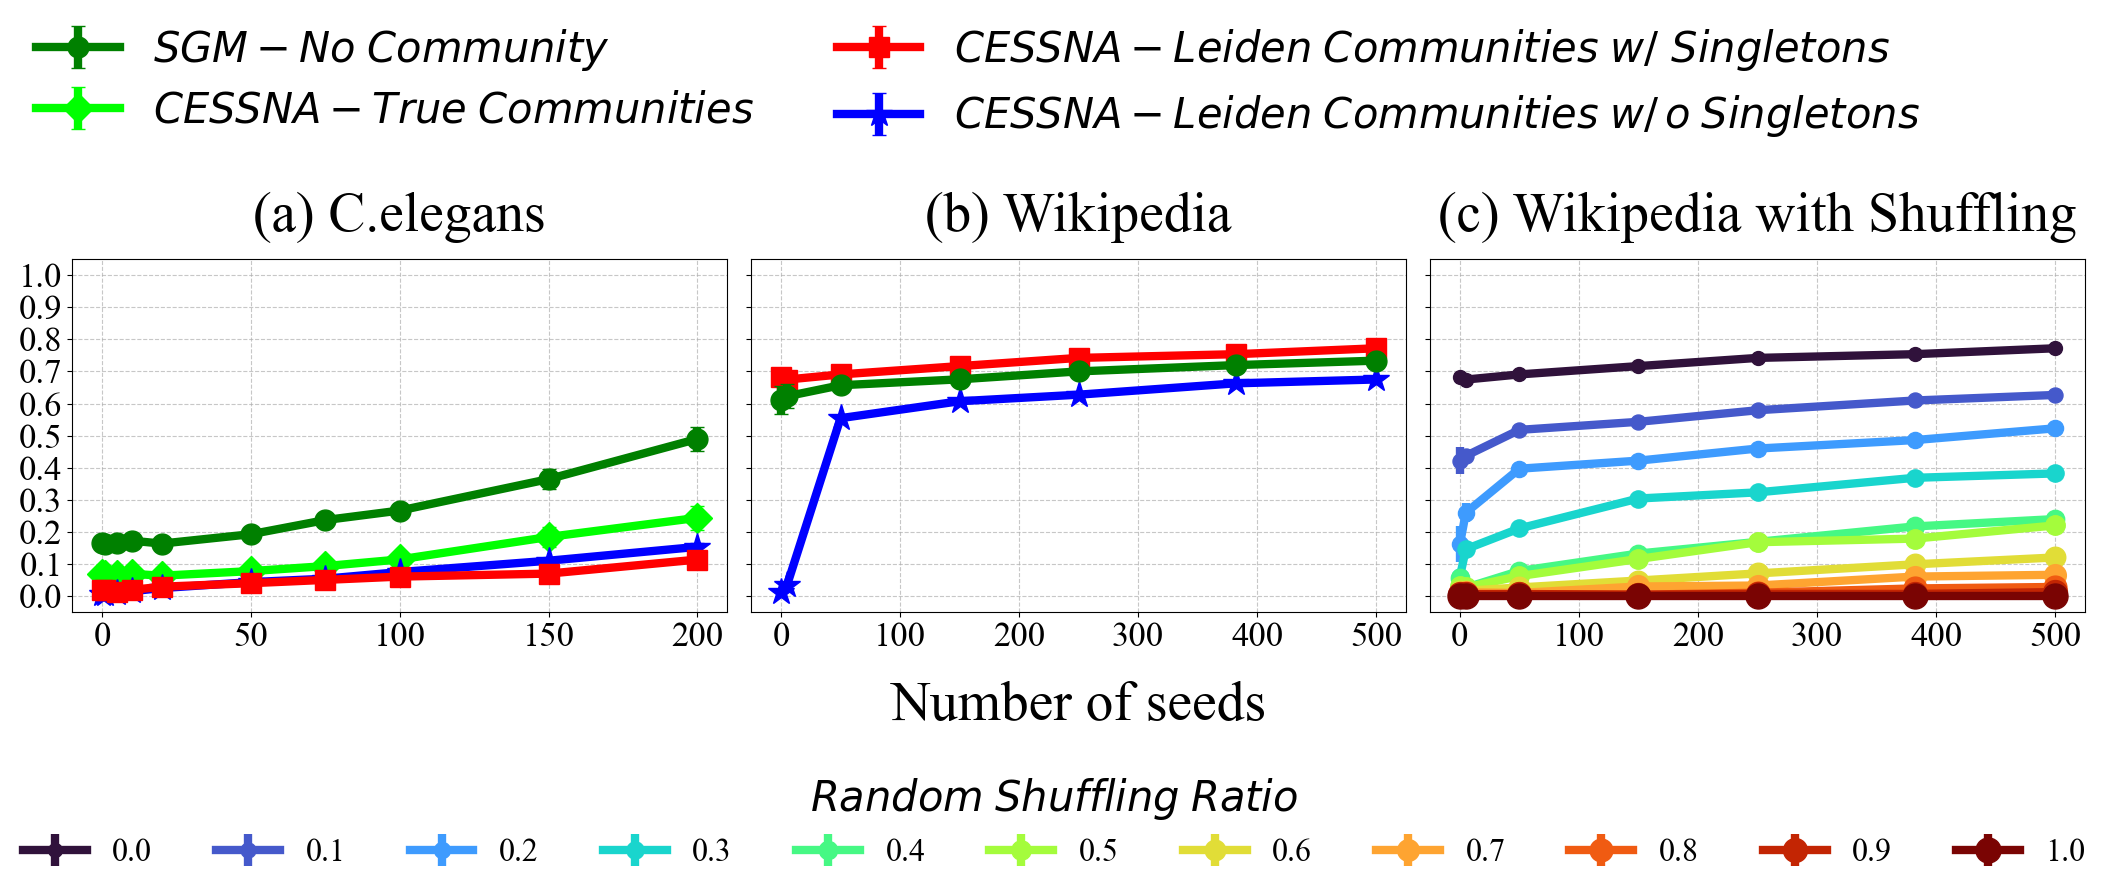

In [45]:
#Figure 3: color-blind friendly version

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import ListedColormap
from matplotlib.font_manager import FontProperties

plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = 'Times New Roman'


cmap = plt.get_cmap('turbo')
colors = cmap(np.linspace(0, 1, n_colors))
discrete_turbo = ListedColormap(colors)

fig, (ax0, ax1, ax2) = plt.subplots(1, 3, figsize=(21, 6), sharey=True)

common_fontsize = 18
title_size = 40

ax0.set_title('(a) C.elegans', fontsize=title_size, pad=20)



line1 = ax0.errorbar(
    x, [0.16572476452446444,
        0.16428392169984943,
        0.16640213885588187,
        0.17332497622546902,
        0.1643620364550597,
        0.19354118005483903,
        0.23756463772585346,
        0.2671667492642694,
        0.36496794475440886,
        0.4900344767042824],
    yerr=errors2,
    fmt='-o',
    linewidth=6, markersize=15,
    color='green', ecolor='green', capsize=5,
    label='CESSNA -- Leiden Community with Singletons'
)

line2 = ax0.errorbar(
    x, final_elegans_without_singletons_means,
    yerr=errors2,
    fmt='-D',
    linewidth=6, markersize=15,
    color='lime', ecolor='lime', capsize=5,
    label='CESSNA -- Leiden Community without Singletons'
)

line4 = ax0.errorbar(
    x, sgm_mean, yerr=sgm_std,
    fmt='-*',
    linewidth=6, markersize=20,
    color='blue', ecolor='blue', capsize=5,
    label='SGM -- No Community'
)

line3 = ax0.errorbar(
    x, [0.0185, 0.0195, 0.0126, 0.0203, 0.0302, 0.0411, 0.0514, 0.0616, 0.0709, 0.1146],
    yerr=errors,
    fmt='-s',
    linewidth=6, markersize=15,
    color='red', ecolor='red', capsize=5,
    label='CESSNA -- True Community'
)



ax0.tick_params(axis='both', which='major', labelsize=common_fontsize)
ax0.tick_params(axis='y', labelsize=25)
ax0.tick_params(axis='x', labelsize=25)
ax0.grid(True, linestyle='--', alpha=0.7)
ax0.set_ylim(-0.05, 1.05)
ax0.set_yticks(np.arange(0, 1.1, 0.1))
ax0.tick_params(axis='y', labelsize=25)

ax1.plot(
    seeds, new_third_plot_result[0],
    marker='s', linestyle='-',
    linewidth=6, color='red',
    label='CESSNA -- True Community',
    markersize=15
)

ax1.errorbar(
    seeds,
    [0.6111866859623733, 0.6227886710239651, 0.6570570570570571,
     0.6754626342692536, 0.7002194149852303, 0.7197758513255883,
     0.7335865955711465],
    yerr=std_devs_array,
    marker='o', linestyle='-',
    color='green', linewidth=6,
    label='CESSNA -- Leiden Community',
    markersize=15, capsize=5
)


ax1.plot(
    seeds,
    [0.0135, 0.0346, 0.5546, 0.6073, 0.6277, 0.6630, 0.675],
    linewidth=6,
    marker='*', linestyle='-',
    color='blue',
    label='SGM -- No Community',
    markersize=20,
)


ax1.set_xlabel('Number of seeds', fontsize=title_size, labelpad=20)
ax1.set_ylabel('')
ax1.set_title('(b) Wikipedia', fontsize=title_size, pad=20)
ax1.tick_params(axis='both', which='major', labelsize=common_fontsize)
ax1.set_xticks(x_axis)
ax1.tick_params(axis='x', labelsize=25)
ax1.grid(True, linestyle='--', alpha=0.7)
ax1.set_ylim(-0.05, 1.05)
ax1.set_yticks([0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0])
ax1.grid(True, axis='y', linestyle='--', alpha=0.7)
ax1.tick_params(axis='y', labelleft=False)

legend_handles2 = []
legend_labels2 = []
base_ms = 10
max_ms = 18
for i, percentage in enumerate(percentages):
    color = discrete_turbo(i / (n_colors - 1))
    ratio = percentage / 100.0
    ms = base_ms + (max_ms - base_ms) * ratio
    line = ax2.errorbar(
        seeds, new_third_plot_result[percentage],
        yerr=std_2d_list[i],
        marker='o', linestyle='-', linewidth=6,
        markersize=ms,
        color=color, label=f'{ratio:.1f}'
    )
    legend_handles2.append(line)
    legend_labels2.append(f'{ratio:.1f}')

ax2.set_ylabel('')
ax2.set_title('(c) Wikipedia with Shuffling', fontsize=title_size, pad=20)
ax2.tick_params(axis='both', which='major', labelsize=common_fontsize)
ax2.set_xticks(x_axis)
ax2.tick_params(axis='x', labelsize=25)
ax2.grid(True, linestyle='--', alpha=0.7)
ax2.set_ylim(-0.05, 1.05)
ax2.grid(True, axis='y', linestyle='--', alpha=0.7)
ax2.tick_params(axis='y', labelleft=False)

font_prop = FontProperties(family='Times New Roman', size=23)
font_prop2 = FontProperties(family='Times New Roman', size=30)
font_prop3 = FontProperties(family='Times New Roman', size=30)

fig.legend(
    [line1, line2, line3, line4],
    ['$SGM - No\\; Community$',
     '$CESSNA - True \\;Communities$',
     '$CESSNA - Leiden\\; Communities\\; w/\\ Singletons$',
     '$CESSNA - Leiden\\; Communities\\; w/\\,o \\;Singletons$'],
    loc='lower right', bbox_to_anchor=(0.5, 1.0, 0.43, 0.5),
    ncol=2, frameon=False, prop=font_prop3,
    title_fontproperties=font_prop3
)

fig.legend(
    legend_handles2, legend_labels2,
    loc='lower center', bbox_to_anchor=(0.5, -0.2),
    title=r'$Random \;Shuffling\; Ratio$',
    ncol=n_colors, frameon=False,
    prop=font_prop, title_fontproperties=font_prop2
)

plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.show()

In [57]:
# code from https://arxiv.org/pdf/2405.05177, information metric used by figure 4
import random
import numpy as np
from scipy.special import loggamma
from collections import defaultdict

def logmultiset(N,K):
    """logarithm of multiset coefficient"""
    return loggamma(N+K-1+1) - loggamma(K+1) - loggamma(N-1+1)

def zero_log(x):
    """log of zero is zero"""
    if x <= 0: return 0
    else: return np.log(x)

def ent(vec):
    """entropy of a distribution"""
    vec  = np.array(vec)/sum(vec)
    return -sum([x*zero_log(x) for x in vec])

def jaccard(A, B):
    """Jaccard index of sets A and B"""
    return len(A & B) / (len(A) + len(B) - len(A & B))

def NMI(N,e1,e2):
    """normalized mutual information between N-node graphs with edge sets e1, e2"""
    Nc2 = N*(N-1)/2
    E1,E2,E12,Union = len(e1),len(e2),len(e1.intersection(e2)),len(e1.union(e2))
    p1,p2,p12 = E1/Nc2,E2/Nc2,E12/Nc2
    H1,H2 = ent([p1,1-p1]), ent([p2,1-p2])
    MI = H1 + H2 - ent([p12,p1-p12,p2-p12,1-p1-p2+p12])
    NMI = (2*MI+1e-100)/(H1+H2+1e-100) # negligibly small constants for the empty and complete graphs
    return NMI

def DCNMI(N,e1,e2):
    """degree-corrected normalized mutual information between N-node graphs with edge sets e1, e2"""
    adj1,adj2 = defaultdict(set),defaultdict(set)
    for e in e1:
        i,j = e
        if not(i in adj1): adj1[i] = set([])
        if not(j in adj1): adj1[j] = set([])
        adj1[i].add(j)
        adj1[j].add(i)
    for e in e2:
        i,j = e
        if not(i in adj2): adj2[i] = set([])
        if not(j in adj2): adj2[j] = set([])
        adj2[i].add(j)
        adj2[j].add(i)
    DCH1,DCH2,DCMI = 0,0,0
    for i in range(N):
        p1i,p2i,p12i = len(adj1[i])/N,len(adj2[i])/N,len(adj1[i].intersection(adj2[i]))/N
        DCH1 += ent([p1i,1-p1i])
        DCH2 += ent([p2i,1-p2i])
        DCMI += ent([p1i,1-p1i]) + ent([p2i,1-p2i]) - ent([p12i,p1i-p12i,p2i-p12i,1-p1i-p2i+p12i])
    DCNMI = (2*DCMI+1e-100)/(DCH1+DCH2+1e-100) # negligibly small constants for the empty and complete graphs
    return DCNMI

def mesosNMI(N,e1,e2,partition):
    """mesoscale normalized mutual information between N-node graphs with edge sets e1, e2 and reference partition"""
    B = len(set(partition))
    Bc2 = B*(B-1)/2
    E1,E2 = len(e1),len(e2)

    table1,table2 = defaultdict(int),defaultdict(int)
    for e in e1:
        i,j = e
        r,s = sorted([partition[i],partition[j]])
        if not((r,s) in table1): table1[(r,s)] = 0
        table1[(r,s)] += 1
    for e in e2:
        i,j = e
        r,s = sorted([partition[i],partition[j]])
        if not((r,s) in table2): table2[(r,s)] = 0
        table2[(r,s)] += 1

    E12 = 0
    pairs = set(list(table1.keys())+list(table2.keys()))
    for pair in pairs:
        E12 += min(table1[pair],table2[pair])

    H1,H2,H12 = logmultiset(Bc2+B,E1),logmultiset(Bc2+B,E2),logmultiset(Bc2+B,E1+E2-E12)
    I = H1 + H2 - H12
    I0 = H1 + H2 - logmultiset(Bc2+B,E1+E2)

    return (I - I0 +1e-100)/((H1+H2)/2 - I0 +1e-100)

def mesosNMI_w_E12(N,e1,e2,partition):
    """mesoscale normalized mutual information between N-node graphs with edge sets e1, e2 and reference partition"""
    B = len(set(partition))
    Bc2 = B*(B-1)/2
    E1,E2 = len(e1),len(e2)

    table1,table2 = defaultdict(int),defaultdict(int)
    for e in e1:
        i,j = e
        r,s = sorted([partition[i],partition[j]])
        if not((r,s) in table1): table1[(r,s)] = 0
        table1[(r,s)] += 1
    for e in e2:
        i,j = e
        r,s = sorted([partition[i],partition[j]])
        if not((r,s) in table2): table2[(r,s)] = 0
        table2[(r,s)] += 1

    E12 = 0
    pairs = set(list(table1.keys())+list(table2.keys()))
    for pair in pairs:
        E12 += min(table1[pair],table2[pair])

    H1,H2,H12 = logmultiset(Bc2+B,E1),logmultiset(Bc2+B,E2),logmultiset(Bc2+B,E1+E2-E12)
    I = H1 + H2 - H12
    I0 = H1 + H2 - logmultiset(Bc2+B,E1+E2)

    return (I - I0 +1e-100)/((H1+H2)/2 - I0 +1e-100), E12


def mesoNMI_details(N,e1,e2,partition):
    """mesoscale normalized mutual information between N-node graphs with edge sets e1, e2 and reference partition"""
    B = len(set(partition))
    Bc2 = B*(B-1)/2
    E1,E2 = len(e1),len(e2)

    table1,table2 = defaultdict(int),defaultdict(int)
    for e in e1:
        i,j = e
        r,s = sorted([partition[i],partition[j]])
        if not((r,s) in table1): table1[(r,s)] = 0
        table1[(r,s)] += 1
    for e in e2:
        i,j = e
        r,s = sorted([partition[i],partition[j]])
        if not((r,s) in table2): table2[(r,s)] = 0
        table2[(r,s)] += 1

    E12 = 0
    pairs = set(list(table1.keys())+list(table2.keys()))
    for pair in pairs:
        E12 += min(table1[pair],table2[pair])

    H1,H2,H12 = logmultiset(Bc2+B,E1),logmultiset(Bc2+B,E2),logmultiset(Bc2+B,E1+E2-E12)
    I = H1 + H2 - H12
    I0 = H1 + H2 - logmultiset(Bc2+B,E1+E2)
    meso = (I - I0 +1e-100)/((H1+H2)/2 - I0 +1e-100)
    return H1, H2, H12, E12, I, I0, meso



def typeI(Gset, eps):
    """Type I noise over fraction eps of nodes in decreasing order of degree""" # to get the random attack, modify `degree_order`

    def degree_order(dict_node_order):
        """returns node_order sorted by highest-degree"""
        node_degrees={node: len(neighbors) for node, neighbors in dict_node_order.items()}
        sorted_nodes=sorted(node_degrees, key=node_degrees.get, reverse=True)
        return {node: dict_node_order[node] for node in sorted_nodes}

    adjlist = {}
    for e in Gset:
        i,j = e
        if not(i in adjlist):
            adjlist[i] = []
        if not(j in adjlist):
            adjlist[j] = []
        adjlist[i].append(j)
        adjlist[j].append(i)
    N = len(adjlist)

    # create placeholders for both the addition and removal of edges from graph G
    new_edges = set()
    old_edges = set()

    # loop through epsilon*N nodes
    deg_order  = degree_order(adjlist)
    node_order = list(deg_order.keys())
    for i in node_order[:int(eps * N)]:
        for neig in adjlist[i]:
            if neig > i:
                repeated = True
                while repeated == True:
                    to_add = tuple(sorted([i, i]))  # Initialize to (i, i) to enter the while loop
                    while to_add[1] == i:
                        to_add = tuple(sorted([i, random.randint(0, N-1)]))
                    if not(to_add in new_edges) and not(to_add in Gset) and not(to_add in old_edges) and to_add[0]!=to_add[1]:
                        old_edges.add(tuple(sorted([i,neig])))
                        new_edges.add(tuple(sorted(to_add)))
                        repeated = False

    Gset_new = Gset.difference(old_edges)
    Gset_new = Gset_new.union(new_edges)

    return Gset_new

def typeII(Gset, eps):
    """Type II noise over fraction eps of edges"""
    N = 1 + max(max(edge) for edge in Gset) # number of nodes
    edges = Gset.copy()
    new_edges = set()
    rand_ij = eps*len(edges)
    count = 0
    while count < rand_ij:
        to_add = (random.choice(range(N)), random.choice(range(N)))
        if to_add[0]!=to_add[1] and not(to_add in edges) and not((to_add[1], to_add[0]) in edges) and not(to_add in new_edges) and not((to_add[1], to_add[0]) in new_edges):
            to_add = (min(to_add), max(to_add)) # imposes i < j for all edges (i,j)
            edges.pop()
            new_edges.add(to_add)
            count += 1
        else:
            pass

    return new_edges.union(edges)

def typeIII(Gset, partition, eps):
    """Type III noise over community-community edges"""
    import time
    timeout = .1 # set a timeout in seconds

    N = len(partition) # number of nodes
    comms = sorted(list(set(partition)))
    B = len(comms)

    edges = {}
    for edge in Gset:
        i,j = edge
        r,s = sorted([partition[i],partition[j]])
        if not((r,s) in edges):
            edges[(r,s)] = set()
        edges[(r,s)].add((i,j))

    comm_sets = {l:[] for l in comms}
    for i in range(N):
        comm_sets[partition[i]].append(i)

    for rs in edges.keys():
        new_edges=set()
        r,s = rs
        rand_rs = int(eps*len(edges[(r,s)]))
        count = 0
        start_time = time.time()
        while count < rand_rs and (time.time() - start_time) < timeout:
            to_add = (random.choice(comm_sets[r]),random.choice(comm_sets[s]))
            if not(to_add in new_edges) and not((to_add[1],to_add[0]) in new_edges) and (to_add[0] != to_add[1]) and not(to_add in edges[(r,s)]) and not((to_add[1],to_add[0]) in edges[(r,s)]):
                edges[(r,s)].pop()
                new_edges.add(to_add)
                count += 1
            else:
                pass
        edges[(r,s)] = new_edges.union(edges[(r,s)])

    return set().union(*list(edges.values()))

In [ ]:
!pip install igraph
!pip install leidenalg

0.39981588093527104
12.0


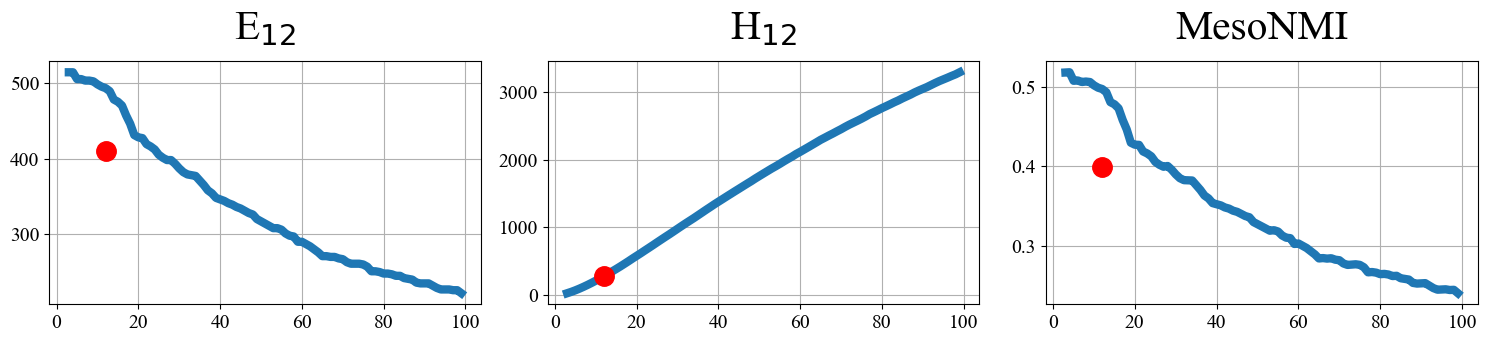

In [60]:
# Figure 4 -- top

import scipy.io
import igraph as ig
import leidenalg as la

def merge_singletons(communities):
    singletons = []
    merged = []
    for comm in communities:
        if len(comm) == 1:
            singletons.append(comm[0])
        else:
            merged.append(comm)
    if singletons:
        merged.append(singletons)
    return merged

def find_element_indices(two_d_list):
    element_to_index = {}
    for i, sublist in enumerate(two_d_list):
        for element in sublist:
            element_to_index[element] = i
    n = sum(len(sublist) for sublist in two_d_list)
    result = [element_to_index[i] for i in range(n)]
    return result

def divide_largest_community(labels, num_communities):
    unique, counts = np.unique(labels, return_counts=True)
    label_counts = dict(zip(unique, counts))

    current_communities = len(unique)
    labels = labels.copy()
    next_label = max(unique) + 1

    while current_communities < num_communities:
        largest_label = max(label_counts, key=label_counts.get)
        largest_count = label_counts[largest_label]

        half_1 = largest_count // 2
        half_2 = largest_count - half_1

        indices = np.where(labels == largest_label)[0]
        labels[indices[:half_1]] = largest_label
        labels[indices[half_1:]] = next_label

        label_counts[largest_label] = half_1
        label_counts[next_label] = half_2

        next_label += 1
        current_communities += 1

    return labels

def adjacency_to_edge_set(adj_matrix):
    edges = set()
    N = adj_matrix.shape[0]
    for i in range(N):
        for j in range(i+1, N):
            if adj_matrix[i, j] != 0:
                edges.add((i, j))
    return edges

elegans_labels = scipy.io.loadmat('celegans_labels.mat')
elegans = scipy.io.loadmat('elegansGraph.mat')

graphA = elegans['Achem'].tocsr()
graphB = elegans['Agap'].tocsr()
labels_vec = elegans_labels['cel_labels'].flatten()

graphA_edges = adjacency_to_edge_set(graphA)
graphB_edges = adjacency_to_edge_set(graphB)

graph_B = ig.Graph.Adjacency(graphB.toarray().tolist(), mode="undirected")
la_partition_wiki = list(la.find_partition(graph_B, la.ModularityVertexPartition))

x = list(range(3, 100))
E_12 = []
H1 = []
H2 = []
H12 = []
meso = []

averaged_meso = []
averaged_num_c = []
averaged_meso_E12 = []
averaged_meso_H1 = []
averaged_meso_H2 = []
averaged_meso_H12 = []

for i in range(20):
  la_partition_wiki = merge_singletons(list(la.find_partition(graph_B, la.ModularityVertexPartition)))
  averaged_num_c.append(len(la_partition_wiki))
  H1_wiki, H2_wiki, H12_wiki, E12_wiki, I_wiki, I0_wiki, meso_wiki = mesoNMI_details(279, graphA_edges, graphB_edges, find_element_indices(la_partition_wiki))
  averaged_meso_E12.append(E12_wiki)
  averaged_meso.append(meso_wiki)
  averaged_meso_H1.append(H1_wiki)
  averaged_meso_H2.append(H2_wiki)
  averaged_meso_H12.append(H12_wiki)

print(np.mean(averaged_meso))
print(np.mean(averaged_num_c))

for i in x:
    new_labels = divide_largest_community(labels_vec, i)
    H1_wiki, H2_wiki, H12_wiki, E12_wiki, I_wiki, I0_wiki, meso_wiki = mesoNMI_details(279, graphA_edges, graphB_edges, new_labels)
    H1.append(H1_wiki)
    H2.append(H2_wiki)
    H12.append(H12_wiki)
    E_12.append(E12_wiki)
    meso.append(meso_wiki)

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharex=True)

data = [E_12, H12, meso]
titles = ['E$_{12}$', 'H$_{12}$', 'MesoNMI']

for ax, dat, tl in zip(axes, data, titles):
    ax.plot(x, dat, linewidth=6)
    ax.set_title(tl, fontsize=30, fontweight='bold', pad=16)
    ax.tick_params(axis='both', labelsize=14)
    ax.grid(True)

axes[-1].plot(np.mean(averaged_num_c), np.mean(averaged_meso), 'o', color='red', markersize=14)
axes[-2].plot(np.mean(averaged_num_c), np.mean(averaged_meso_H12), 'o', color='red', markersize=14)
axes[-3].plot(np.mean(averaged_num_c), np.mean(averaged_meso_E12), 'o', color='red', markersize=14)
plt.tight_layout(rect=[0, 0.07, 1, 0.95])
plt.show()

0.8351366807664276
8.7


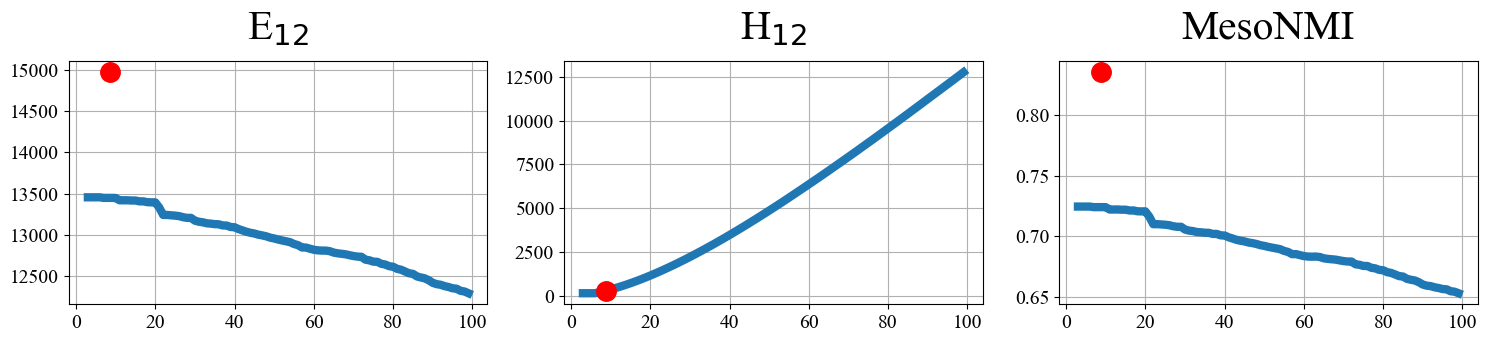

In [67]:
# Figure 4 -- bottom


wiki_labels = scipy.io.loadmat('wiki_labels.mat')
wiki_adj = scipy.io.loadmat('wiki_adj.mat')

graphA = wiki_adj['G_EN_Adj']
graphB = wiki_adj['G_FR_Adj']
labels_vec = wiki_labels['wiki_labels'].flatten()

graphA_edges = adjacency_to_edge_set(graphA)
graphB_edges = adjacency_to_edge_set(graphB)

graph_B = ig.Graph.Adjacency(graphB.tolist(), mode="undirected")
la_partition_wiki = list(la.find_partition(graph_B, la.ModularityVertexPartition))

x = list(range(3, 100))
E_12 = []
H1 = []
H2 = []
H12 = []
meso = []

averaged_meso = []
averaged_num_c = []
averaged_meso_E12 = []
averaged_meso_H1 = []
averaged_meso_H2 = []
averaged_meso_H12 = []

for i in range(20):
  la_partition_wiki = merge_singletons(list(la.find_partition(graph_B, la.ModularityVertexPartition)))
  averaged_num_c.append(len(la_partition_wiki))
  H1_wiki, H2_wiki, H12_wiki, E12_wiki, I_wiki, I0_wiki, meso_wiki = mesoNMI_details(279, graphA_edges, graphB_edges, find_element_indices(la_partition_wiki))
  averaged_meso_E12.append(E12_wiki)
  averaged_meso.append(meso_wiki)
  averaged_meso_H1.append(H1_wiki)
  averaged_meso_H2.append(H2_wiki)
  averaged_meso_H12.append(H12_wiki)

print(np.mean(averaged_meso))
print(np.mean(averaged_num_c))

for i in x:
    new_labels = divide_largest_community(labels_vec, i)
    H1_wiki, H2_wiki, H12_wiki, E12_wiki, I_wiki, I0_wiki, meso_wiki = mesoNMI_details(279, graphA_edges, graphB_edges, new_labels)
    H1.append(H1_wiki)
    H2.append(H2_wiki)
    H12.append(H12_wiki)
    E_12.append(E12_wiki)
    meso.append(meso_wiki)

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharex=True)

data = [E_12, H12, meso]
titles = ['E$_{12}$', 'H$_{12}$', 'MesoNMI']

for ax, dat, tl in zip(axes, data, titles):
    ax.plot(x, dat, linewidth=6)
    ax.set_title(tl, fontsize=30, fontweight='bold', pad=16)
    ax.tick_params(axis='both', labelsize=14)
    ax.grid(True)

axes[-1].plot(np.mean(averaged_num_c), np.mean(averaged_meso), 'o', color='red', markersize=14)
axes[-2].plot(np.mean(averaged_num_c), np.mean(averaged_meso_H12), 'o', color='red', markersize=14)
axes[-3].plot(np.mean(averaged_num_c), np.mean(averaged_meso_E12), 'o', color='red', markersize=14)
plt.tight_layout(rect=[0, 0.07, 1, 0.95])
plt.show()

<>:101: SyntaxWarning: invalid escape sequence '\;'
<>:109: SyntaxWarning: invalid escape sequence '\;'
<>:101: SyntaxWarning: invalid escape sequence '\;'
<>:109: SyntaxWarning: invalid escape sequence '\;'
/tmp/ipykernel_2936/224248834.py:101: SyntaxWarning: invalid escape sequence '\;'
  label='$Without\; Communities$'
/tmp/ipykernel_2936/224248834.py:109: SyntaxWarning: invalid escape sequence '\;'
  label='$With\; Communities$'


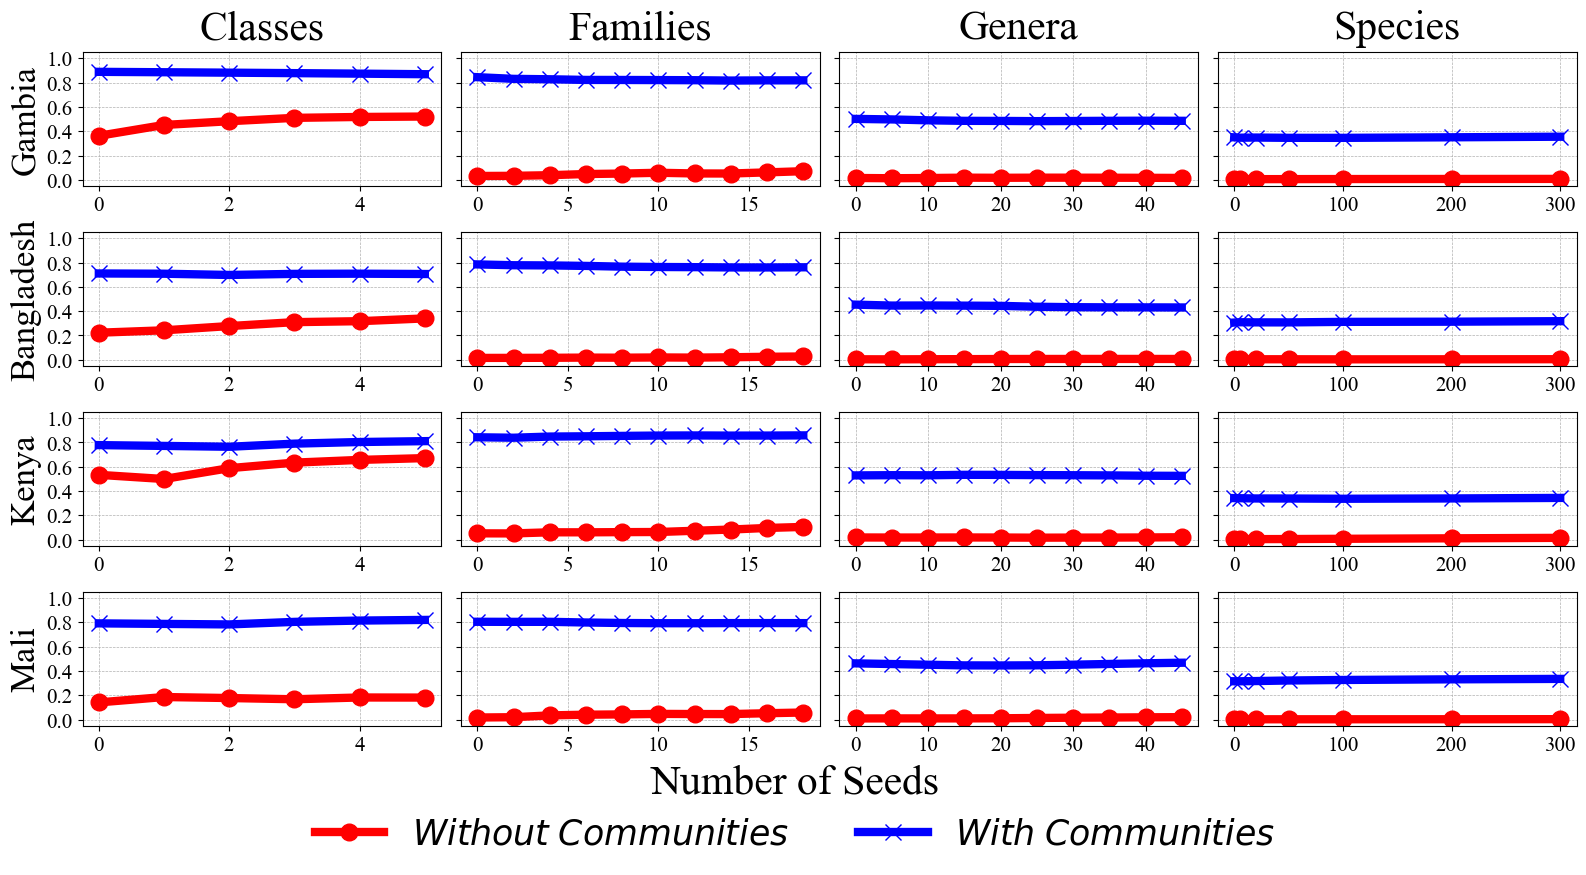

In [48]:
# Figure 5

numbers = []


with open('within_country.txt', 'r') as f:
    content = f.read()


matches = re.findall(r'\d+\.\d{2,}', content)

within_country_accs = [float(x) for x in matches]
within_with = within_country_accs[1::2]
within_without = within_country_accs[0::2]

Gambia2 = [within_without[3:9],
within_with[3:9],
within_without[9:19],
within_with[9:19],
within_without[19:29],
within_with[19:29],
within_without[29:36],
within_with[29:36]]

Bangladesh2 = [within_without[39:45],
within_with[39:45],
within_without[45:55],
within_with[45:55],
within_without[55:65],
within_with[55:65],
within_without[65:72],
within_with[65:72]]

Kenya2 = [within_without[75:81],
within_with[75:81],
within_without[81:91],
within_with[81:91],
within_without[91:101],
within_with[91:101],
within_without[101:108],
within_with[101:108]]

Mali2 = [within_without[111:117],
within_with[111:117],
within_without[117:127],
within_with[117:127],
within_without[127:137],
within_with[127:137],
within_without[137:144],
within_with[137:144]]

coun2 = [Gambia2,  Bangladesh2, Kenya2, Mali2]

xaxis_class = [0,1,2,3,4,5]
xaxis_Family = [0, 2, 4, 6, 8, 10, 12, 14, 16, 18]
xaxis_Genus = [0, 5, 10, 15, 20, 25, 30, 35, 40, 45]
xaxis_Species = [0,5,20,50,100,200,300]


title_fontsize = 30
ylabel_fontsize = 25
tick_fontsize = 15
line_width = 6
marker_style1 = 'o'
marker_style2 = 'x'
marker_size = 12

col_titles = ['Classes', 'Families', 'Genera', 'Species']
row_titles = ['Gambia', 'Bangladesh', 'Kenya', 'Mali']

xaxis_class = [0, 1, 2, 3, 4, 5]
xaxis_Family = [0, 2, 4, 6, 8, 10, 12, 14, 16, 18]
xaxis_Genus = [0, 5, 10, 15, 20, 25, 30, 35, 40, 45]
xaxis_Species = [0, 5, 20, 50, 100, 200, 300]
x_axes = [xaxis_class, xaxis_Family, xaxis_Genus, xaxis_Species]


fig_width = 4 * 4
fig_height = 4 * 2

fig, axes = plt.subplots(4, 4, figsize=(fig_width, fig_height))
for i, country in enumerate(['Gambia', 'Bangladesh', 'Kenya', 'Mali']):
    data = coun2[i]
    for j in range(4):
        ax = axes[i, j]
        idx1, idx2 = 2*j, 2*j+1
        this_x = x_axes[j]
        l1 = ax.plot(
            this_x, data[idx1],
            color='red',
            linewidth=line_width,
            marker=marker_style1,
            markersize=marker_size,
            label='$Without\; Communities$'
        )
        l2 = ax.plot(
            this_x, data[idx2],
            color='blue',
            linewidth=line_width,
            marker=marker_style2,
            markersize=marker_size,
            label='$With\; Communities$'
        )

        ax.set_ylim(-0.05, 1.05)
        ax.grid(True, which='both', linestyle='--', linewidth=0.5)
        ax.tick_params(axis='both', which='major', labelsize=tick_fontsize)


        if j == 0:
            ax.set_yticks(np.arange(0.0, 1.01, 0.2))
            if i == 0:
                ax.set_ylabel(row_titles[i], fontsize=ylabel_fontsize)
            else:
                ax.set_ylabel('')
        else:
            ax.set_yticks(np.arange(0.0, 1.01, 0.2))
            ax.tick_params(axis='y', labelleft=False)
            ax.set_ylabel('')


        ax.grid(True, which='both', linestyle='--', linewidth=0.5)
        ax.tick_params(axis='both', which='major', labelsize=tick_fontsize)

        if i == 0:
            ax.set_title(col_titles[j], fontsize=title_fontsize,pad=10)
        if j == 0:
            ax.set_ylabel(row_titles[i], fontsize=ylabel_fontsize)


handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc='lower center',
    ncol=2,
    bbox_to_anchor=(0.5, -0.11),
    fontsize=25,
    frameon=False
)

fig.text(
    0.5,
    -0.01,
    "Number of Seeds",
    ha='center',
    va='bottom',
    fontsize=30
)
plt.tight_layout(rect=[0, 0.03, 1, 1])
plt.show()


In [77]:
# Figure 6 data:
Bangladesh_family_control_case = [0.8126760563380282, 0.7985507246376812,0.7970149253731343,0.7938461538461539,0.7936507936507937
, 0.7803278688524589,0.7796610169491525,0.7859649122807016,0.801818181818182,0.7735849056603774]
Bangladesh_genus_control_case = [0.4573170731707317, 0.46037735849056605,0.43896103896103894,0.43154362416107384,0.4333333333333334,0.4532374100719424,0.47238805970149256,0.5124031007751938,0.5137096774193548,0.5210084033613445]
Bangladesh_species_control_case = [0.3183023872679045, 0.30507343124165553,0.31607629427792916,
                                   0.33096590909090906,0.35015290519877673,0.3601083032490975,0.3612334801762115]
cross_country = {'phylum': [[0.33333333333333337, 0.5, 0.7142857142857143],
  [0.6888888888888889, 0.675, 0.6857142857142857],
  [1.0, 1.0, 1.0],
  [1.0, 1.0, 1.0],
  [0.5555555555555556, 0.5, 0.5714285714285714],
  [0.3111111111111111, 0.525, 0.48571428571428565],
  [0.7777777777777778, 0.75, 0.7142857142857143],
  [0.7777777777777778, 0.75, 0.7142857142857143],
  [1.0, 1.0, 1.0],
  [0.7777777777777778, 0.75, 0.7142857142857143],
  [1.0, 1.0, 1.0],
  [0.7777777777777778, 0.75, 0.7142857142857143],
  [0.7777777777777778, 0.75, 0.7142857142857143],
  [0.7777777777777778, 0.75, 0.7142857142857143]],
 'class': [[0.2777777777777778,
   0.49411764705882355,
   0.275,
   0.3066666666666667,
   0.6142857142857142,
   0.7692307692307692],
  [0.43888888888888883,
   0.6941176470588235,
   0.8,
   0.78,
   0.7642857142857142,
   0.7461538461538462],
  [0.9222222222222222, 0.9294117647058823, 0.925, 1.0, 1.0, 1.0],
  [0.888888888888889,
   0.8823529411764707,
   0.875,
   0.8666666666666668,
   0.8571428571428571,
   0.8461538461538461],
  [0.23333333333333334,
   0.6,
   0.7,
   0.49333333333333335,
   0.4714285714285714,
   0.7538461538461538],
  [0.43888888888888894,
   0.5117647058823529,
   0.475,
   0.4066666666666666,
   0.5428571428571429,
   0.5153846153846153],
  [0.2828282828282828,
   0.625668449197861,
   0.7045454545454546,
   0.5272727272727273,
   0.5064935064935064,
   0.7622377622377623],
  [0.4696969696969697,
   0.53475935828877,
   0.5,
   0.4484848484848485,
   0.5714285714285714,
   0.5454545454545454],
  [0.888888888888889,
   0.8823529411764707,
   0.875,
   0.8666666666666668,
   0.8571428571428571,
   0.8461538461538461],
  [0.7222222222222221,
   0.7294117647058823,
   0.6875,
   0.7333333333333333,
   0.7142857142857143,
   0.6923076923076923],
  [0.888888888888889,
   0.8823529411764707,
   0.875,
   0.8666666666666668,
   0.8571428571428571,
   0.8461538461538461],
  [0.7777777777777778,
   0.7647058823529411,
   0.75,
   0.8666666666666668,
   0.8571428571428571,
   0.8461538461538461],
  [0.7222222222222221,
   0.6823529411764706,
   0.7125,
   0.7333333333333333,
   0.7142857142857143,
   0.6923076923076923],
  [0.7777777777777778,
   0.7647058823529411,
   0.75,
   0.8666666666666668,
   0.8571428571428571,
   0.8461538461538461]],
 'family': [[0.029577464788732393,
   0.03333333333333334,
   0.07313432835820895,
   0.053846153846153856,
   0.06507936507936507,
   0.06885245901639345,
   0.13559322033898305,
   0.09824561403508772,
   0.2309090909090909,
   0.23962264150943396],
  [0.06901408450704224,
   0.07681159420289856,
   0.10298507462686568,
   0.08153846153846155,
   0.08253968253968254,
   0.10655737704918031,
   0.14915254237288136,
   0.14561403508771925,
   0.13818181818181816,
   0.14150943396226415],
  [0.6591549295774648,
   0.6463768115942029,
   0.6388059701492537,
   0.64,
   0.6523809523809524,
   0.6344262295081968,
   0.6305084745762712,
   0.6421052631578947,
   0.6327272727272726,
   0.6188679245283019],
  [0.6619718309859155,
   0.6565217391304349,
   0.6791044776119403,
   0.6630769230769231,
   0.6682539682539683,
   0.6622950819672131,
   0.6694915254237288,
   0.656140350877193,
   0.6545454545454545,
   0.6867924528301886],
  [0.011267605633802818,
   0.008695652173913044,
   0.04029850746268656,
   0.04153846153846154,
   0.03968253968253968,
   0.044262295081967204,
   0.09661016949152543,
   0.09473684210526315,
   0.10363636363636364,
   0.12452830188679245],
  [0.09436619718309859,
   0.07971014492753623,
   0.06865671641791045,
   0.09538461538461537,
   0.09523809523809522,
   0.1,
   0.09661016949152543,
   0.08421052631578946,
   0.11636363636363636,
   0.12641509433962264],
  [0.6901408450704226,
   0.6855072463768116,
   0.7014925373134329,
   0.673846153846154,
   0.6952380952380952,
   0.6786885245901639,
   0.6728813559322033,
   0.6631578947368421,
   0.6781818181818181,
   0.6962264150943395],
  [0.6309859154929578,
   0.6478260869565218,
   0.6313432835820895,
   0.6230769230769232,
   0.6333333333333332,
   0.6672131147540983,
   0.6966101694915253,
   0.687719298245614,
   0.690909090909091,
   0.7132075471698114],
  [0.828169014084507,
   0.8420289855072463,
   0.8253731343283583,
   0.8184615384615386,
   0.8222222222222222,
   0.8295081967213115,
   0.8016949152542374,
   0.8105263157894738,
   0.8054545454545454,
   0.8],
  [0.7845070422535211,
   0.7565217391304347,
   0.7791044776119402,
   0.7584615384615384,
   0.7571428571428571,
   0.740983606557377,
   0.747457627118644,
   0.7526315789473684,
   0.7563636363636363,
   0.7811320754716982],
  [0.8323943661971832,
   0.8144927536231885,
   0.8238805970149254,
   0.826153846153846,
   0.8317460317460317,
   0.8245901639344261,
   0.8118644067796611,
   0.8070175438596492,
   0.8181818181818181,
   0.809433962264151],
  [0.8464788732394366,
   0.8289855072463768,
   0.8552238805970148,
   0.8600000000000001,
   0.8682539682539682,
   0.8508196721311476,
   0.8694915254237289,
   0.8578947368421052,
   0.858181818181818,
   0.8867924528301888],
  [0.7746478873239437,
   0.7536231884057971,
   0.7671641791044775,
   0.7707692307692307,
   0.753968253968254,
   0.7557377049180328,
   0.7576271186440677,
   0.7526315789473684,
   0.7618181818181818,
   0.7943396226415095],
  [0.8380281690140846,
   0.8362318840579709,
   0.8477611940298507,
   0.8553846153846155,
   0.8746031746031747,
   0.8557377049180328,
   0.8525423728813559,
   0.8526315789473685,
   0.8545454545454545,
   0.8867924528301886]],
 'genus': [[np.float64(0.013414634146341465),
   np.float64(0.015723270440251576),
   np.float64(0.00909090909090909),
   np.float64(0.014765100671140941),
   np.float64(0.014583333333333332),
   np.float64(0.07338129496402876),
   np.float64(0.0791044776119403),
   np.float64(0.0806201550387597),
   np.float64(0.08548387096774195),
   np.float64(0.07058823529411765)],
  [np.float64(0.0628048780487805),
   np.float64(0.07169811320754717),
   np.float64(0.06558441558441556),
   np.float64(0.06241610738255034),
   np.float64(0.07569444444444444),
   np.float64(0.07266187050359711),
   np.float64(0.0955223880597015),
   np.float64(0.09379844961240309),
   np.float64(0.0935483870967742),
   np.float64(0.09831932773109245)],
  [np.float64(0.3640243902439025),
   np.float64(0.36855345911949683),
   np.float64(0.37272727272727274),
   np.float64(0.3516778523489933),
   np.float64(0.3666666666666667),
   np.float64(0.3906474820143885),
   np.float64(0.3977611940298508),
   np.float64(0.4263565891472868),
   np.float64(0.425),
   np.float64(0.426890756302521)],
  [np.float64(0.41402439024390236),
   np.float64(0.4025157232704403),
   np.float64(0.39935064935064934),
   np.float64(0.3832214765100671),
   np.float64(0.37916666666666665),
   np.float64(0.37841726618705035),
   np.float64(0.4231343283582089),
   np.float64(0.4542635658914729),
   np.float64(0.4516129032258064),
   np.float64(0.46302521008403363)],
  [0.017073170731707322,
   0.0169811320754717,
   0.00974025974025974,
   0.01610738255033557,
   0.0125,
   0.017985611510791366,
   0.01641791044776119,
   0.015503875968992248,
   0.018548387096774192,
   0.034453781512605045],
  [0.00975609756097561,
   0.014465408805031447,
   0.008441558441558441,
   0.014093959731543626,
   0.028472222222222225,
   0.023741007194244608,
   0.041044776119402986,
   0.03488372093023255,
   0.0282258064516129,
   0.018487394957983194],
  [0.38902439024390245,
   0.3691823899371069,
   0.38441558441558443,
   0.3859060402684563,
   0.38819444444444445,
   0.3575539568345324,
   0.36716417910447763,
   0.39069767441860465,
   0.38870967741935486,
   0.3966386554621849],
  [0.40975609756097564,
   0.4182389937106918,
   0.4240259740259741,
   0.4174496644295302,
   0.4395833333333333,
   0.42230215827338136,
   0.42462686567164176,
   0.46899224806201556,
   0.4508064516129032,
   0.46974789915966386],
  [0.499390243902439,
   0.5044025157232704,
   0.4824675324675324,
   0.4671140939597316,
   0.47361111111111115,
   0.46546762589928053,
   0.49402985074626865,
   0.4829457364341085,
   0.48467741935483877,
   0.4831932773109243],
  [0.44329268292682933,
   0.4364779874213836,
   0.43701298701298696,
   0.4402684563758389,
   0.4291666666666667,
   0.4064748201438849,
   0.39850746268656717,
   0.41395348837209306,
   0.4467741935483871,
   0.43613445378151267],
  [0.5036585365853659,
   0.4937106918238993,
   0.48376623376623373,
   0.4885906040268456,
   0.4805555555555555,
   0.48057553956834526,
   0.49179104477611935,
   0.49302325581395345,
   0.4983870967741935,
   0.48655462184873954],
  [0.526829268292683,
   0.5465408805031446,
   0.5383116883116884,
   0.5308724832214765,
   0.5201388888888889,
   0.4978417266187051,
   0.526865671641791,
   0.5279069767441861,
   0.4975806451612903,
   0.5260504201680671],
  [0.4469512195121951,
   0.44905660377358486,
   0.4454545454545455,
   0.4429530201342281,
   0.44375,
   0.40431654676259,
   0.4052238805970149,
   0.42248062015503873,
   0.4266129032258064,
   0.4310924369747899],
  [0.5213414634146342,
   0.5339622641509434,
   0.5318181818181819,
   0.5288590604026845,
   0.5326388888888889,
   0.5035971223021584,
   0.5194029850746269,
   0.5085271317829457,
   0.4975806451612904,
   0.5285714285714285]],
 'species': [[0.007957559681697614,
   0.008544726301735648,
   0.010899182561307902,
   0.010511363636363635,
   0.006422018348623852,
   0.02563176895306859,
   0.025991189427312777],
  [0.004244031830238726,
   0.004272363150867824,
   0.009809264305177113,
   0.011079545454545455,
   0.009174311926605503,
   0.015884476534296026,
   0.014977973568281937],
  [0.2891246684350133,
   0.2966622162883845,
   0.27929155313351495,
   0.2872159090909091,
   0.2944954128440367,
   0.30361010830324914,
   0.33568281938325994],
  [0.3,
   0.3102803738317757,
   0.30217983651226155,
   0.3014204545454545,
   0.3253822629969419,
   0.3386281588447654,
   0.35594713656387666],
  [0.0,
   0.001068090787716956,
   0.0010899182561307902,
   0.0008522727272727272,
   0.0030581039755351687,
   0.006498194945848375,
   0.007048458149779736],
  [0.003978779840848806,
   0.006408544726301736,
   0.005449591280653951,
   0.006534090909090909,
   0.00672782874617737,
   0.005415162454873647,
   0.003964757709251102],
  [0.270026525198939,
   0.28037383177570097,
   0.26920980926430516,
   0.2696022727272728,
   0.28837920489296637,
   0.28050541516245486,
   0.3158590308370044],
  [0.29257294429708225,
   0.29399198931909215,
   0.2893732970027248,
   0.28892045454545456,
   0.300611620795107,
   0.2963898916967509,
   0.32246696035242295],
  [0.34933687002652525,
   0.3535380507343124,
   0.3400544959128065,
   0.3502840909090909,
   0.35137614678899076,
   0.37328519855595665,
   0.3876651982378855],
  [0.306896551724138,
   0.3060080106809079,
   0.31008174386920984,
   0.3065340909090909,
   0.3305810397553517,
   0.32671480144404336,
   0.34185022026431716],
  [0.3506631299734748,
   0.34632843791722295,
   0.355858310626703,
   0.34573863636363633,
   0.3489296636085627,
   0.3696750902527076,
   0.3872246696035242],
  [0.3350132625994695,
   0.33965287049399195,
   0.33651226158038144,
   0.33948863636363635,
   0.3324159021406728,
   0.34657039711191334,
   0.37092511013215856],
  [0.3103448275862069,
   0.310547396528705,
   0.30544959128065396,
   0.30397727272727276,
   0.33058103975535175,
   0.3256317689530686,
   0.34625550660792953],
  [0.34190981432360745,
   0.33724966622162883,
   0.3337874659400545,
   0.3403409090909091,
   0.32477064220183494,
   0.3444043321299639,
   0.36651982378854625]]}

numbers2 = []
with open('cross_country.txt', 'r') as f:
    for line in f:
        line = line.strip()
        if line and (line[0].isdigit() or (line[0] == '.' and len(line) > 1 and line[1].isdigit())):
            try:
                numbers2.append(float(line))
            except ValueError:
                continue

print(numbers2)
Gambia_family_control_case = cross_country['family'][8]
Mali_family_control_case = cross_country['family'][9]
Kenya_family_control_case = cross_country['family'][11]

Gambia_genus_control_case = cross_country['genus'][8]
Mali_genus_control_case = cross_country['genus'][9]
Kenya_genus_control_case = cross_country['genus'][11]

Gambia_species_control_case = cross_country['species'][8]
Mali_species_control_case = cross_country['species'][9]
Kenya_species_control_case = cross_country['species'][11]

Gambia_Mali_family_control = [numbers2[74],numbers2[82],numbers2[90],numbers2[98],numbers2[106],numbers2[114],numbers2[122],numbers2[130],numbers2[138],numbers2[146]]
Gambia_Mali_genus_control = [numbers2[154],numbers2[162],numbers2[170],numbers2[178],numbers2[186],numbers2[194],numbers2[202],numbers2[210],numbers2[218],numbers2[226]]
Gambia_Mali_species_control = [numbers2[234],numbers2[242],numbers2[250],numbers2[258],numbers2[266],numbers2[274],numbers2[282]]

Gambia_Mali_family_case = [numbers2[75],numbers2[83],numbers2[91],numbers2[99],numbers2[107],numbers2[115],numbers2[123],numbers2[131],numbers2[139],numbers2[147]]
Gambia_Mali_genus_case = [numbers2[155],numbers2[163],numbers2[171],numbers2[179],numbers2[187],numbers2[195],numbers2[203],numbers2[211],numbers2[219],numbers2[227]]
Gambia_Mali_species_case = [numbers2[235],numbers2[243],numbers2[251],numbers2[259],numbers2[267],numbers2[275],numbers2[283]]

Gambia_Mali_family_control_case = [numbers2[78],numbers2[86],numbers2[94],numbers2[102],numbers2[110],numbers2[118],numbers2[126],numbers2[134],numbers2[142],numbers2[150]]
Gambia_Mali_genus_control_case = [numbers2[158],numbers2[166],numbers2[174],numbers2[182],numbers2[190],numbers2[198],numbers2[206],numbers2[214],numbers2[222],numbers2[230]]
Gambia_Mali_species_control_case = [numbers2[238],numbers2[246],numbers2[254],numbers2[262],numbers2[270],numbers2[278],numbers2[286]]

Gambia_Mali_family_case_control = [numbers2[79],numbers2[87],numbers2[95],numbers2[103],numbers2[111],numbers2[119],numbers2[127],numbers2[135],numbers2[143],numbers2[151]]
Gambia_Mali_genus_case_control = [numbers2[159],numbers2[167],numbers2[175],numbers2[183],numbers2[191],numbers2[199],numbers2[207],numbers2[215],numbers2[223],numbers2[231]]
Gambia_Mali_species_case_control = [numbers2[239],numbers2[247],numbers2[255],numbers2[263],numbers2[271],numbers2[279],numbers2[287]]

Gambia_Kenya_family_control = [numbers2[362],numbers2[370],numbers2[378],numbers2[386],numbers2[394],numbers2[402],numbers2[410],numbers2[418],numbers2[426],numbers2[434]]
Gambia_Kenya_genus_control = [numbers2[442],numbers2[450],numbers2[458],numbers2[466],numbers2[474],numbers2[482],numbers2[490],numbers2[498],numbers2[506],numbers2[514]]
Gambia_Kenya_species_control = [numbers2[522],numbers2[530],numbers2[538],numbers2[546],numbers2[554],numbers2[562],numbers2[570]]

Gambia_Kenya_family_case = [numbers2[363],numbers2[371],numbers2[379],numbers2[387],numbers2[395],numbers2[403],numbers2[411],numbers2[419],numbers2[427],numbers2[435]]
Gambia_Kenya_genus_case = [numbers2[443],numbers2[451],numbers2[459],numbers2[467],numbers2[475],numbers2[483],numbers2[491],numbers2[499],numbers2[507],numbers2[515]]
Gambia_Kenya_species_case = [numbers2[523],numbers2[531],numbers2[539],numbers2[547],numbers2[555],numbers2[563],numbers2[571]]

Gambia_Kenya_family_control_case = [numbers2[366],numbers2[374],numbers2[382],numbers2[390],numbers2[398],numbers2[406],numbers2[414],numbers2[422],numbers2[430],numbers2[438]]
Gambia_Kenya_genus_control_case = [numbers2[446],numbers2[454],numbers2[462],numbers2[470],numbers2[478],numbers2[486],numbers2[494],numbers2[502],numbers2[510],numbers2[518]]
Gambia_Kenya_species_control_case = [numbers2[526],numbers2[534],numbers2[542],numbers2[550],numbers2[558],numbers2[566],numbers2[574]]

Gambia_Kenya_family_case_control = [numbers2[367],numbers2[375],numbers2[383],numbers2[391],numbers2[399],numbers2[407],numbers2[415],numbers2[423],numbers2[431],numbers2[439]]
Gambia_Kenya_genus_case_control = [numbers2[447],numbers2[455],numbers2[463],numbers2[471],numbers2[479],numbers2[487],numbers2[495],numbers2[503],numbers2[511],numbers2[519]]
Gambia_Kenya_species_case_control = [numbers2[527],numbers2[535],numbers2[543],numbers2[551],numbers2[559],numbers2[567],numbers2[575]]

Mali_Kenya_family_control = [numbers2[650],numbers2[658],numbers2[666],numbers2[674],numbers2[682],numbers2[690],numbers2[698],numbers2[706],numbers2[714],numbers2[722]]
Mali_Kenya_genus_control = [numbers2[730],numbers2[738],numbers2[746],numbers2[754],numbers2[762],numbers2[770],numbers2[778],numbers2[786],numbers2[794],numbers2[802]]
Mali_Kenya_species_control = [numbers2[810],numbers2[818],numbers2[826],numbers2[834],numbers2[842],numbers2[850],numbers2[858]]

Mali_Kenya_family_case = [numbers2[651],numbers2[659],numbers2[667],numbers2[675],numbers2[683],numbers2[691],numbers2[699],numbers2[707],numbers2[715],numbers2[723]]
Mali_Kenya_genus_case = [numbers2[731],numbers2[739],numbers2[747],numbers2[755],numbers2[763],numbers2[771],numbers2[779],numbers2[787],numbers2[795],numbers2[803]]
Mali_Kenya_species_case = [numbers2[811],numbers2[819],numbers2[827],numbers2[835],numbers2[843],numbers2[851],numbers2[859]]

Mali_Kenya_family_control_case = [numbers2[654],numbers2[662],numbers2[670],numbers2[678],numbers2[686],numbers2[694],numbers2[702],numbers2[710],numbers2[718],numbers2[726]]
Mali_Kenya_genus_control_case = [numbers2[734],numbers2[742],numbers2[750],numbers2[758],numbers2[766],numbers2[774],numbers2[782],numbers2[790],numbers2[798],numbers2[806]]
Mali_Kenya_species_control_case = [numbers2[814],numbers2[822],numbers2[830],numbers2[838],numbers2[846],numbers2[854],numbers2[862]]

Mali_Kenya_family_case_control = [numbers2[655],numbers2[663],numbers2[671],numbers2[679],numbers2[687],numbers2[695],numbers2[703],numbers2[711],numbers2[719],numbers2[727]]
Mali_Kenya_genus_case_control = [numbers2[735],numbers2[743],numbers2[751],numbers2[759],numbers2[767],numbers2[775],numbers2[783],numbers2[791],numbers2[799],numbers2[807]]
Mali_Kenya_species_case_control = [numbers2[815],numbers2[823],numbers2[831],numbers2[839],numbers2[847],numbers2[855],numbers2[863]]

colors = ['blue', 'dodgerblue', 'green', 'lime', 'red', 'darkorange']
blues = [Gambia_family_control_case, Gambia_family_control_case, Mali_family_control_case,
         Gambia_genus_control_case, Gambia_genus_control_case, Mali_genus_control_case,
         Gambia_species_control_case, Gambia_species_control_case, Mali_species_control_case]

dodgerblues = [Mali_family_control_case, Kenya_family_control_case, Kenya_family_control_case,
               Mali_genus_control_case, Kenya_genus_control_case, Kenya_genus_control_case,
               Mali_species_control_case, Kenya_species_control_case, Kenya_species_control_case]
greens = [Gambia_Mali_family_control_case, Gambia_Kenya_family_control_case, Mali_Kenya_family_control_case,
          Gambia_Mali_genus_control_case, Gambia_Kenya_genus_control_case, Mali_Kenya_genus_control_case,
          Gambia_Mali_species_control_case, Gambia_Kenya_species_control_case, Mali_Kenya_species_control_case]
limes = [Gambia_Mali_family_case_control, Gambia_Kenya_family_case_control, Mali_Kenya_family_case_control,
          Gambia_Mali_genus_case_control, Gambia_Kenya_genus_case_control, Mali_Kenya_genus_case_control,
          Gambia_Mali_species_case_control, Gambia_Kenya_species_case_control, Mali_Kenya_species_case_control]
reds = [Gambia_Mali_family_control, Gambia_Kenya_family_control, Mali_Kenya_family_control,
        Gambia_Mali_genus_control, Gambia_Kenya_genus_control, Mali_Kenya_genus_control,
        Gambia_Mali_species_control, Gambia_Kenya_species_control, Mali_Kenya_species_control]
darkoranges = [Gambia_Mali_family_case, Gambia_Kenya_family_case, Mali_Kenya_family_case,
               Gambia_Mali_genus_case, Gambia_Kenya_genus_case, Mali_Kenya_genus_case,
               Gambia_Mali_species_case, Gambia_Kenya_species_case, Mali_Kenya_species_case]

[0.5555555555555556, 0.5555555555555556, 1.0, 0.7777777777777778, 0.6444444444444445, 0.6666666666666667, 0.7777777777777778, 1.0, 0.5, 0.45, 1.0, 0.75, 0.6, 0.625, 0.75, 1.0, 0.42857142857142855, 0.6285714285714287, 1.0, 0.7142857142857143, 0.5714285714285714, 0.5714285714285714, 0.7142857142857143, 1.0, 0.26666666666666666, 0.3055555555555556, 0.7444444444444445, 0.888888888888889, 0.25555555555555554, 0.2611111111111112, 0.3131313131313131, 0.31818181818181823, 0.5294117647058822, 0.41764705882352937, 0.7176470588235294, 0.8823529411764707, 0.49411764705882344, 0.48235294117647054, 0.5294117647058822, 0.5080213903743315, 0.5, 0.5125, 0.7, 0.875, 0.5625, 0.5, 0.5909090909090909, 0.5340909090909091, 0.5066666666666666, 0.6533333333333333, 0.7333333333333333, 0.8666666666666668, 0.5133333333333333, 0.4666666666666667, 0.5454545454545454, 0.503030303030303, 0.32857142857142857, 0.6214285714285716, 0.7142857142857143, 0.8571428571428571, 0.5214285714285714, 0.42857142857142866, 0.5519480

<>:9: SyntaxWarning: invalid escape sequence '\;'
<>:9: SyntaxWarning: invalid escape sequence '\;'
<>:10: SyntaxWarning: invalid escape sequence '\;'
<>:10: SyntaxWarning: invalid escape sequence '\;'
<>:11: SyntaxWarning: invalid escape sequence '\;'
<>:11: SyntaxWarning: invalid escape sequence '\;'
<>:9: SyntaxWarning: invalid escape sequence '\;'
<>:9: SyntaxWarning: invalid escape sequence '\;'
<>:10: SyntaxWarning: invalid escape sequence '\;'
<>:10: SyntaxWarning: invalid escape sequence '\;'
<>:11: SyntaxWarning: invalid escape sequence '\;'
<>:11: SyntaxWarning: invalid escape sequence '\;'
/tmp/ipykernel_2936/2922904821.py:9: SyntaxWarning: invalid escape sequence '\;'
  array_names = ['$Contry\; 1 \;Case \;vs. \;Control$', '$Contry \;1 \;Case\; vs. \;Control$',
/tmp/ipykernel_2936/2922904821.py:9: SyntaxWarning: invalid escape sequence '\;'
  array_names = ['$Contry\; 1 \;Case \;vs. \;Control$', '$Contry \;1 \;Case\; vs. \;Control$',
/tmp/ipykernel_2936/2922904821.py:10: Sy

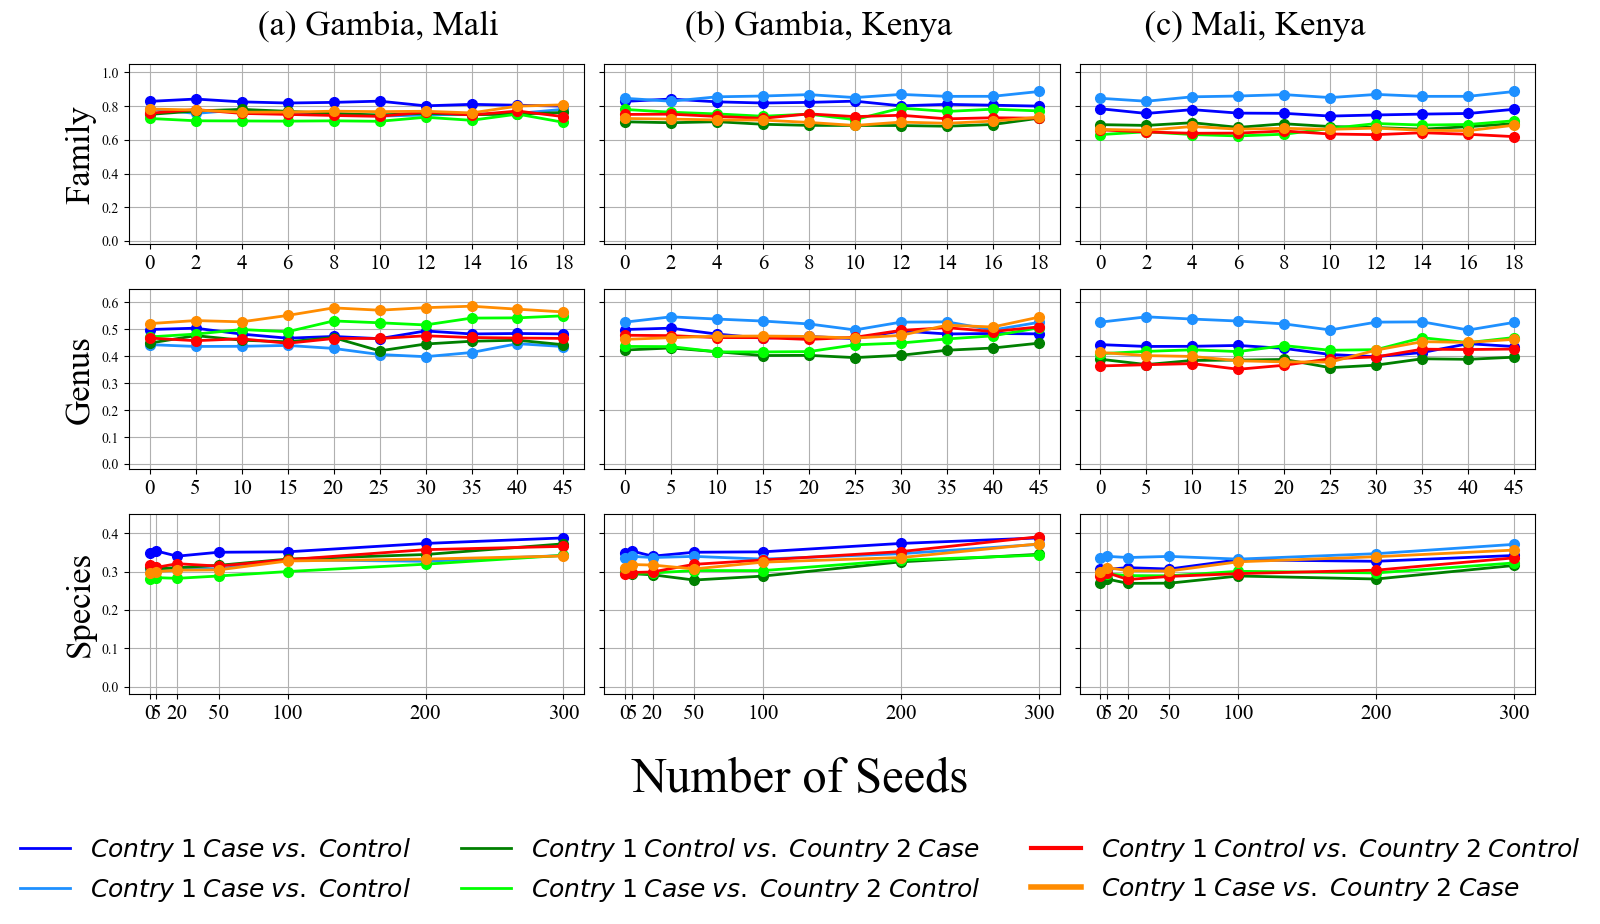

In [78]:
import matplotlib.pyplot as plt

def plot_six_color_arrays(
    blues, dodgerblues, greens, limes, reds, darkoranges,
    line_width=2, marker_size=7
):
    colors = ['blue', 'dodgerblue', 'green', 'lime', 'red', 'darkorange']
    arrays = [blues, dodgerblues, greens, limes, reds, darkoranges]
    array_names = ['$Contry\; 1 \;Case \;vs. \;Control$', '$Contry \;1 \;Case\; vs. \;Control$',
                   '$Contry \;1 \;Control \;vs. \;Country \;2 \;Case$', '$Contry \;1\; Case \;vs. \;Country\; 2\; Control$',
                   '$Contry \;1\; Control \;vs.\; Country \;2 \;Control$', '$Contry\; 1\; Case \;vs.\; Country\; 2 \;Case$']
    ylabels = ['Family', 'Genus', 'Species']

    xlabels = [
        [0,2,4,6,8,10,12,14,16,18],
        [0,5,10,15,20,25,30,35,40,45],
        [0,5,20,50,100,200,300]
    ]
    ylim_rows = [(-0.02, 1.05), (-0.02, 0.65), (-0.02, 0.45)]
    yticks_rows = [
        [0, 0.2, 0.4, 0.6, 0.8, 1.0],
        [0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6],
        [0, 0.1, 0.2, 0.3, 0.4]
    ]
    column_titles = ["(a) Gambia, Mali       ", "(b) Gambia, Kenya", "      (c) Mali, Kenya"]
    fig, axes = plt.subplots(3, 3, figsize=(15, 7.5))
    axes = axes.flatten()


    for col in range(3):
        xpos = (axes[col].get_position().x0 + axes[col].get_position().x1) / 2
        plt.gcf().text(xpos, 1.01, column_titles[col], ha='center', va='bottom', fontsize=25)



    for i in range(9):
        r = i // 3
        c = i % 3
        ax = axes[i]
        for arr, color, name in zip(arrays, colors, array_names):
            ax.plot(
                xlabels[r][:len(arr[i])], arr[i],
                color=color,
                label=name,
                linewidth=line_width,
                marker='o',
                markersize=marker_size
            )
        ax.set_ylim(ylim_rows[r])
        ax.grid(True)
        if c == 0:
            ax.set_ylabel(ylabels[r], fontsize=25)
            ax.set_yticks(yticks_rows[r])
            ax.tick_params(axis='y', labelsize=10)
        else:
            ax.set_yticklabels([])
        ax.set_xticks(xlabels[r])
        ax.set_xticklabels(xlabels[r])
        ax.tick_params(axis='x', labelsize=15)


    legend_elements = [
    Line2D([0], [0], color='blue', lw=2, label=array_names[0]),
    Line2D([0], [0], color='dodgerblue', lw=2, label=array_names[1]),
    Line2D([0], [0], color='green', lw=2, label=array_names[2]),
    Line2D([0], [0], color='lime', lw=2, label=array_names[3]),
    Line2D([0], [0], color='red', lw=3, label=array_names[4]),
    Line2D([0], [0], color='darkorange', lw=4, label=array_names[5])
]

    fig.legend(handles=legend_elements, loc='lower center',
            bbox_to_anchor=(0.5, -0.17), ncol=3, fontsize=18, framealpha=0.0)

    fig.text(0.5, 0.01, 'Number of Seeds', ha='center', fontsize=35)
    plt.tight_layout(rect=[0, 0.08, 1, 1])
    plt.show()

plot_six_color_arrays(blues, dodgerblues, greens, limes, reds, darkoranges)